<a href="https://colab.research.google.com/github/annanyanaudiyal24/Data-Science-Project/blob/main/Data_Science_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Terrorism Pattern Analysis
## using the Global Terrorism Database (GTD)

---

> **PROJECT TYPE:** Exploratory Data Analysis (EDA) and ML Models Implementation  
> **Dataset:** Global Terrorism Database (GTD)

---


# Contribution: Individual
> **Name:** Ananya Naudiyal  


# Project Summary

---

# Dataset at a Glance

| Metric | Value |
|-------|------|
| Total Incidents | **181,691** |
| Fatalities | **411,868** |
| Injuries | **523,869** |
| Countries Affected | **205** |

---

The **Global Terrorism Database (GTD)**, maintained by the National Consortium for the Study of Terrorism and Responses to Terrorism (**START**) at the University of Maryland, is one of the most comprehensive open-source repositories of terrorist incidents worldwide.  

It catalogues **181,691 incidents (1970–2017)** across **205 countries**, with **135 attributes per record** spanning temporal, geographic, tactical, and casualty dimensions.

This project performs **Exploratory Data Analysis (EDA)** to uncover global patterns in:
- Frequency  
- Geography  
- Methodology  
- Perpetrators  

It traces nearly five decades of evolution—from Cold War-era political violence to the extremist surge of the 2010s.

Following EDA, **hypothesis testing** was conducted to validate statistical assumptions before applying:
- Supervised Machine Learning models  
- Unsupervised Machine Learning models  

to derive predictive and structural insights.

---

# Key Findings from EDA

| Finding | Insight |
|--------|--------|
| **Geographic Concentration** | Middle East & North Africa + South Asia account for **53%+ of all incidents**, marking them as primary global hotspots. |
| **Dominant Attack Method** | Bombings/Explosions constitute **49% of all attacks**, indicating preference for high-impact methods. |
| **Peak Activity (2014)** | **16,903 incidents** and **44,000+ deaths** in one year — linked to ISIS expansion and conflicts in Iraq, Syria, Afghanistan, and Nigeria. |

---

# Human Toll

- **Fatalities:** 411,868  
- **Injuries:** 523,869  

Injuries consistently outnumber fatalities.  
The **post-2011 period** accounts for the majority of the cumulative human cost.

---

# Machine Learning Models Implemented

Six models were applied across two categories:

## Classification Models

| Model | Description |
|------|------------|
| **Logistic Regression** | Baseline binary classifier; interpretable coefficients quantify feature influence. |
| **Decision Tree** | Rule-based model capturing non-linear relationships; highly interpretable. |
| **Naive Bayes** | Probabilistic classifier; efficient for high-dimensional categorical data. |
| **K-Nearest Neighbours (KNN)** | Instance-based model using similarity; sensitive to feature scaling. |

## Clustering Models

| Model | Description |
|------|------------|
| **Agglomerative Clustering** | Bottom-up hierarchical clustering; identifies natural groupings. |
| **Hierarchical Clustering** | Produces dendrograms for multi-level pattern analysis. |

---

# Methodology Note

Hypothesis testing was conducted **before model training** to:
- Validate distributional assumptions  
- Confirm statistically significant differences across feature groups  

A **comparative accuracy analysis** was then performed across classification models to identify the best-performing approach.

**GIT HUB LINK**:
https://github.com/annanyanaudiyal24/Data-Science-Project/tree/main

**Problem Statement**
* Terrorism remains one of the most destabilizing forces affecting human security, economic
development, and geopolitical stability worldwide. Despite vast amounts of data being collected
on terrorist incidents over decades, governments, security agencies, NGOs, and policy
researchers often lack a structured analytical framework to identify where, when, and how
attacks are most likely to occur, which groups are responsible, and what targets are most at
risk.
* Without actionable intelligence derived from historical data, counter-terrorism strategies remain
reactive rather than proactive, resulting in inefficient resource allocation and inadequate
prevention measures.

**Business Objective**
The primary objectives of this analysis are:
* Identify global hotspots and high-risk regions for terrorist activity to support geographic
resource prioritization.
* Understand temporal trends to detect escalating patterns and forecast future risk
periods.
* Profile the most active terrorist groups and their preferred methods to aid threat
intelligence.
* Analyze target types to help governments, corporations, and institutions strengthen the
security of vulnerable assets.
* Provide evidence-based insights to policy makers and security analysts for designing
effective counter-terrorism frameworks.


**IMPORTING** **LIBRARIES & FILES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
from wordcloud import WordCloud
import missingno as msno

**LOADING** **DATA** **SET**

In [3]:
df = pd.read_csv('Global Terrorism Data.csv', encoding='latin1', low_memory=False)

**Finding** **Rows** **&** **Columns** **of** **datset**

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 181691
Columns: 135


In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,181685.000000,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2.002705e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,1.451452,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,1.325957e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,0.995430,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,1.000000,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,1.000000,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
print(df.head(10))   #Printing first 10 entries of dataset

        eventid  iyear  imonth  iday approxdate  extended resolution  country  \
0  197000000001   1970       7     2        NaN         0        NaN       58   
1  197000000002   1970       0     0        NaN         0        NaN      130   
2  197001000001   1970       1     0        NaN         0        NaN      160   
3  197001000002   1970       1     0        NaN         0        NaN       78   
4  197001000003   1970       1     0        NaN         0        NaN      101   
5  197001010002   1970       1     1        NaN         0        NaN      217   
6  197001020001   1970       1     2        NaN         0        NaN      218   
7  197001020002   1970       1     2        NaN         0        NaN      217   
8  197001020003   1970       1     2        NaN         0        NaN      217   
9  197001030001   1970       1     3        NaN         0        NaN      217   

          country_txt  region  ...  \
0  Dominican Republic       2  ...   
1              Mexico       1  .

**List of data rows and data columns**

In [7]:
print("Shape of dataset:",df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Shape of dataset: (181691, 135)
Rows: 181691
Columns: 135


**Checking & Viewing Duplicate rows**

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df[df.duplicated()]

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related


**Missing Values/Null Values**

In [10]:
df.isnull().sum()

,0
eventid,0
iyear,0
imonth,0
iday,0
approxdate,172452
...,...
INT_LOG,0
INT_IDEO,0
INT_MISC,0
INT_ANY,0


**Visualizing the missing values**

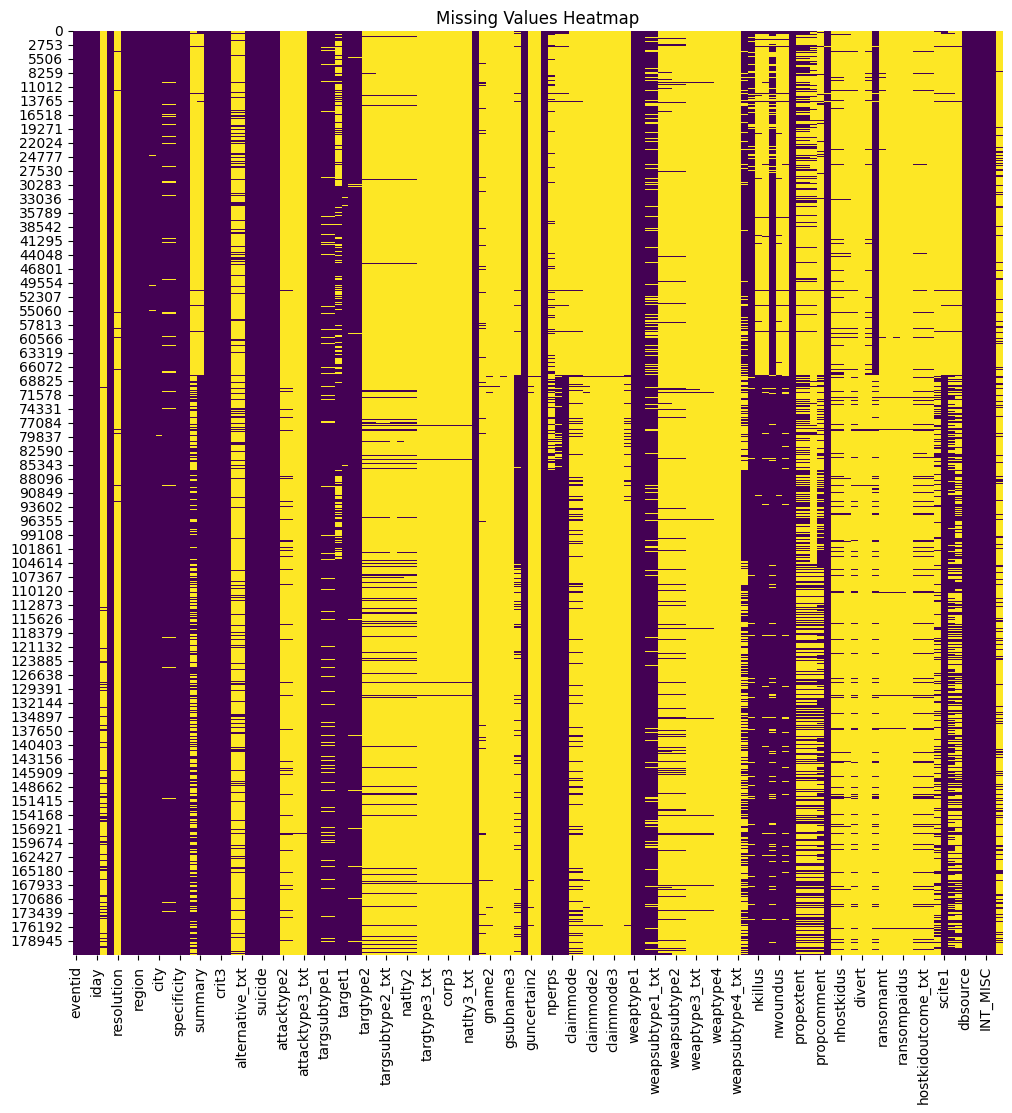

In [11]:
plt.figure(figsize=(12,12))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

**Dataset Overview**
* Structure & Dimensions - The dataset comprises 112,550 records across 135 features, providing a rich multi-dimensional view of global terrorism incidents. The feature set spans numerical measurements, categorical classifications, and free-text annotations.
## Data Type Distribution

| Type | Columns | Description |
|---|---|---|
| `float64` | 70 | Continuous & encoded numerical features |
| `int64` | 7 | Discrete numerical features |
| `object` | 58 | Categorical & free-text fields |


* Data Integrity
* Duplicate Records: The dataset contains zero duplicate rows, confirming that every entry represents a unique incident. No deduplication is required at this stage.
* Missing Values: A notable challenge in this dataset is the prevalence of null values across multiple columns. Preliminary visualizations — including a missingness heatmap and a column-wise bar chart — reveal two distinct tiers of data completeness:
## Missing Data Summary

| Category | Fields | Recommendation |
|---|---|---|
| **Critically Sparse** (near-entirely null) | `approxdate`, `related`, `scite1`, `scite2`, `scite3` | Exclude or impute based on downstream requirements |
| **Moderately Incomplete** (partial nulls) | `addnotes`, `INT_LOG`, `INT_IDEO`, `INT_MISC`, `INT_ANY` | Mode/median imputation, flag encoding, or conditional dropping |
* Addressing missing values will be a primary focus of the Data Wrangling phase to ensure analytical integrity.



## Dataset Variables**

| Variable | Type | Description |
|---|---|---|
| `eventid` | int64 | Primary key — unique ID per incident |
| `iyear` | int64 | Year of incident (1970–2012) |
| `imonth` | int64 | Month (0=unknown, 1–12) |
| `iday` | int64 | Day (0=unknown, 1–31) |
| `country_txt` | object | Country name |
| `region_txt` | object | Geographic region |
| `latitude` | float64 | Lat coordinate ⚠️ missing values |
| `longitude` | float64 | Lon coordinate ⚠️ missing values |
| `attacktype1_txt` | object | Primary attack type |
| `targtype1_txt` | object | Primary target type |
| `nkill` | float64 | Confirmed fatalities ⚠️ missing values |
| `nwound` | float64 | Confirmed wounded ⚠️ missing values |
| `summary` | object | Incident narrative ⚠️ many missing |
| `gname` | object | Perpetrator group name |

**DATA WRANGLING**

**Removing  & Viewing rows  after removing duplicates**

In [12]:
df = df.drop_duplicates()

In [13]:
print("Rows:", df.shape[0])

Rows: 181691


**Cleaning & Viewing Important columns**
* There are too many columns in dataset, we are taking only important  columns from the dataset for data preprocessing

In [14]:
important_cols = [
    'iyear', 'imonth', 'iday', 'country_txt', 'region_txt', 'city',
    'attacktype1_txt', 'targtype1_txt', 'gname', 'weaptype1_txt',
    'nkill', 'nwound', 'success', 'suicide'
]

df_clean = df[important_cols].copy()

**Converting & Viewing Numeric columns**

In [15]:
num_cols = ['iyear', 'imonth', 'iday', 'nkill', 'nwound', 'success', 'suicide']

for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

**Filling Missing values**

In [16]:
cat_cols = ['country_txt', 'region_txt', 'city', 'attacktype1_txt', 'targtype1_txt', 'gname', 'weaptype1_txt']

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

for col in ['nkill', 'nwound', 'success', 'suicide', 'iyear', 'imonth', 'iday']:
    df_clean[col] = df_clean[col].fillna(0)


**Data Cleaning — Incorrect Data Types**

A critical step in the data wrangling pipeline is ensuring each column is stored in its correct data type. Misclassified types can produce silent errors in aggregations, visualisations, and model inputs. The following four sub-tasks were performed systematically.

* Checking current data types
An initial audit of all 135 columns was conducted using `df.dtypes` and `df.dtypes.value_counts()` to establish a baseline. This inspection revealed several columns that were incorrectly inferred by pandas at load time — notably numeric fields stored as `object` and date-related fields lacking a proper temporal structure.

* Converting important numeric columns
Key analytical columns — including `nkill`, `nwound`, `latitude`, and `longitude` — were cast to `float64`, while date-part columns (`iyear`, `imonth`, `iday`) were enforced as nullable integers (`Int64`). The conversion was handled using `pd.to_numeric()` with `errors='coerce'` to ensure any non-numeric entries were safely converted to `NaN` rather than raising exceptions.

* Converting text columns to string
All categorical and free-text columns such as `country_txt`, `region_txt`, `attacktype1_txt`, `gname`, and `summary` were explicitly cast to `string` dtype. Leading and trailing whitespace was stripped, and any residual literal `'nan'` strings — an artefact of the type conversion process — were replaced with proper null values to maintain data integrity.

* Cleaning date-related columns
The three date-part columns (`iyear`, `imonth`, `iday`) were combined to construct a unified `date` column of `datetime64` type. Invalid placeholder values (month or day recorded as `0`) were replaced with `NaT` prior to parsing to prevent malformed dates from entering the analysis. The resulting column enables proper time-series operations and temporal filtering across the dataset.


In [17]:
num_cols = [
    'iyear', 'imonth', 'iday', 'country', 'region', 'latitude', 'longitude',
    'specificity', 'vicinity', 'multiple', 'success', 'suicide', 'attacktype1',
    'attacktype2', 'attacktype3', 'targtype1', 'targtype2', 'targtype3',
    'weaptype1', 'weaptype2', 'weaptype3', 'weaptype4', 'nkill', 'nwound',
    'property', 'propextent', 'ransom', 'nperps'
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [18]:
text_cols = [
    'country_txt', 'region_txt', 'provstate', 'city', 'attacktype1_txt',
    'targtype1_txt', 'gname', 'weaptype1_txt', 'gsubname', 'motive'
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)

In [19]:
for col in ['iyear', 'imonth', 'iday']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

**Create new columns that will help in further evaluation**

In [20]:
df['casualties'] = df['nkill'].fillna(0) + df['nwound'].fillna(0)
df['year'] = df['iyear']
df['decade'] = (df['iyear'] // 10) * 10
df['month_name'] = pd.to_datetime(df['imonth'], format='%m', errors='coerce').dt.month_name()
df['fatal_attack'] = np.where(df['nkill'].fillna(0) > 0, 'Yes', 'No')

In [21]:
df['country_region'] = df['country_txt'].astype(str) + " - " + df['region_txt'].astype(str)
df['high_casualty'] = np.where(df['casualties'] >= df['casualties'].median(), 'High', 'Low')

**DATA MANIPULATIONS**
* STEP 1: Column selection -
The original 135-column dataset was reduced to 14 analytically relevant features — covering temporal identifiers, geography, attack characteristics, perpetrator details, and casualty metrics. Columns with excessive missing values or limited relevance to the core EDA objectives were excluded, resulting in a leaner, more navigable working dataset.
* STEP 2: Handling missing numerical values -
All numeric columns were systematically validated: each was confirmed to exist, coerced to the appropriate numeric dtype, and any non-parseable or invalid entries were replaced with NaN. This ensures downstream aggregations and statistical operations are not distorted by silently corrupt values.
* STEP 3: Handling missing categorical values -
All categorical and free-text columns were explicitly cast to string dtype and standardised. This guarantees consistent behaviour during grouping, filtering, and visualisation operations, and prevents type-related inconsistencies from affecting analysis outcomes.
* STEP 4: Feature engineering -
New derived columns were constructed to enhance analytical utility:
total casualties — sum of nkill and nwound, providing a single composite measure of incident severity.
Additional features were engineered to improve interpretability and support richer visualisation of temporal and geographic trends.
* **KEY INSIGHTS**
1. Simplified data structure - Reducing 135 columns to 14 targeted features significantly improved dataset navigability. The retained columns collectively capture the most critical dimensions of each incident — when, where, how, by whom, and with what impact — without the noise of sparsely populated auxiliary fields.  
2. Data completeness for key metrics - Imputing missing values across critical columns — including nkill, nwound, country_txt, region_txt, attacktype1_txt, and targtype1_txt — ensures these fields can be fully utilised in analysis without introducing bias from row-level data loss.
1.   Direct impact measurement - The engineered total_casualties column consolidates fatalities and injuries into a single, interpretable severity metric. This enables immediate quantification of human impact per incident and supports meaningful trend analysis across regions, attack types, and time periods.




**DATA VISUALIZATION & EXPREIMENTING WITH CHARTS**

**CHART 1: Number of Terrorist Attacks Per Year**

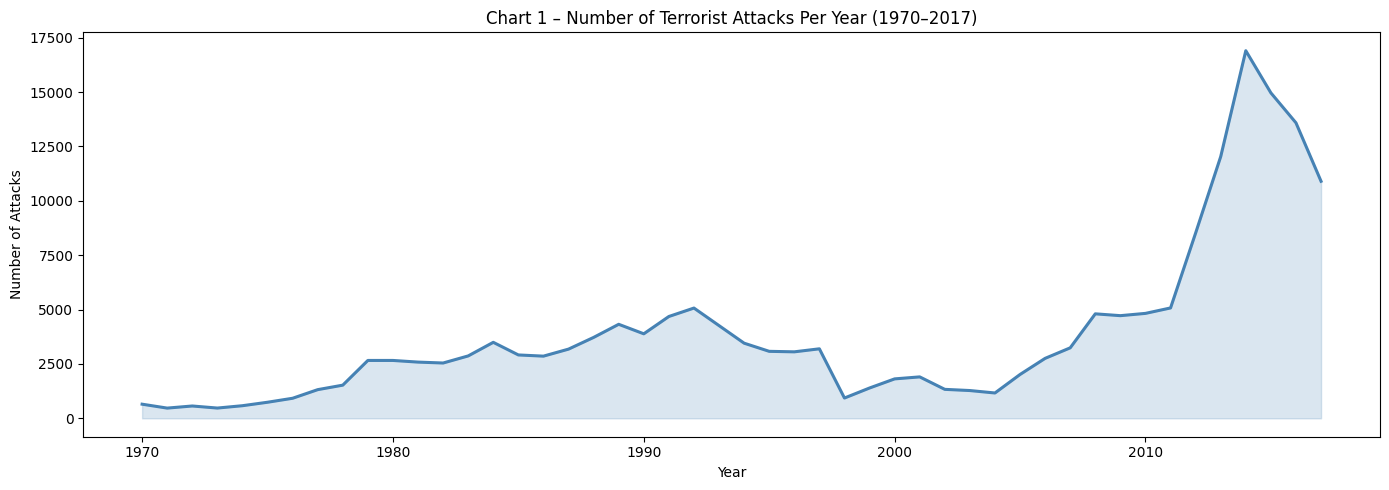

In [22]:

yearly_attacks = df.groupby('year').size().reset_index(name='count')

plt.figure(figsize=(14,5))
plt.plot(yearly_attacks['year'], yearly_attacks['count'], color='steelblue', linewidth=2.2)
plt.fill_between(yearly_attacks['year'], yearly_attacks['count'], alpha=0.2, color='steelblue')

plt.title("Chart 1 – Number of Terrorist Attacks Per Year (1970–2017)")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.tight_layout()
plt.show()



* **Why a filled area line chart?** -
A filled area line chart was selected to visualise continuous temporal trends in annual attack frequency from 1970 to 2017. The line component clearly traces year-on-year movement, while the shaded fill beneath emphasises cumulative volume and the magnitude of change — making the dramatic post-2011 escalation immediately apparent against the flatter earlier decades.
* **The chart reveals five distinct phases in global terrorism activity:**
* 1970 – late 1970s - (~600 → ~2,700)
A steady early rise from minimal baseline activity, accelerating sharply toward 1980.
* 1980 – early 1990s - (~2,500 – ~5,100)
Sustained elevated activity with a notable peak around 1992, driven by geopolitical conflicts across multiple regions.
* Mid-1990s – early 2000s - (~1,000 – ~3,200)
A marked trough bottoming near 1998, followed by subdued recovery — the lowest sustained period in the dataset.
* 2004 – 2011 - (~1,200 → ~5,000)
A renewed and accelerating uptrend, reflecting growing instability across the Middle East, South Asia, and Sub-Saharan Africa
* 2011 – 2017  |  Peak: 2014 - (~5,000 → 16,903 → ~10,900)
An unprecedented surge driven by the rise of ISIL and ongoing conflicts in Iraq, Syria, Afghanistan, and Nigeria. The 2014 peak represents the highest single-year count in the entire dataset. Although activity declined post-2014, volumes remained far above any pre-2012 level, indicating a persistently elevated global threat baseline.




**Business Impact**
* **Positive impact (Strategic opportunities enabled by these insights)** -


1.   Security optimisation - Temporal trend data enables governments and security firms to anticipate high-risk periods and allocate resources proactively, reducing exposure and operational losses.
2.   Informed policy making - Clear escalation signals support the design of targeted counter-terrorism policies and international cooperation frameworks, fostering global stability conducive to trade and investment.
1.   Risk modelling - Insurance, logistics, and tourism sectors can leverage historical frequency data for more accurate risk pricing, route planning, and safety protocol development.
2.   Humanitarian planning - Escalation patterns allow NGOs and aid organisations to pre-position resources in regions approaching crisis thresholds before conditions deteriorate further.

* **Negative growth (Risks indicated by the sustained post-2011 escalation)**


1.   Rising operational costs - Businesses in high-risk regions face elevated security expenditure, higher insurance premiums, and increasing operational complexity — directly compressing margins.
2.   Supply chain disruption - Attacks on transportation corridors introduce delays, cost overruns, and revenue loss for businesses reliant on globally integrated supply chains.
1.   Deterred investment & tourism - Sustained instability suppresses foreign direct investment and visitor arrivals, stalling economic development in the most affected regions
2.   Human capital erosion - Casualties and psychological trauma diminish workforce productivity, increase attrition, and impose long-term costs on organisational resilience.






**Chart 2: Showing number of attacks by year**

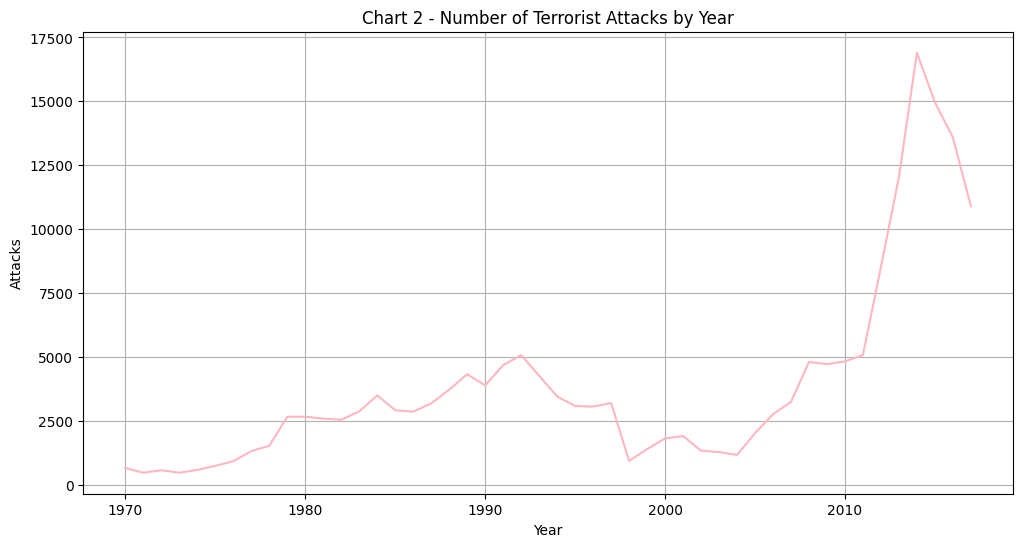

In [23]:
yearly_attacks = df.groupby('year')['eventid'].count()
plt.figure(figsize=(12,6))
yearly_attacks.plot(kind='line', color='lightpink')
plt.title('Chart 2 - Number of Terrorist Attacks by Year')
plt.xlabel('Year')
plt.ylabel('Attacks')
plt.grid(True)
plt.show()

* **Why a filled area line chart?** -
A line chart is the most appropriate choice for visualising a continuously evolving quantitative variable — annual attack frequency — across an unbroken 47-year timeline. The connected data points emphasise directionality and momentum, making gradual shifts, sudden inflections, and sustained trends intuitively readable in a way that discrete chart types cannot replicate.
* **Six distinct phases define the global terrorism trajectory:**
* 1970s – 1980s-
Moderate and fluctuating activity with incremental growth — a period of relatively contained, regionally concentrated terrorism.
* Late 1980s – early 1990s -
A pronounced surge in attack frequency, reflecting escalating geopolitical conflicts across multiple theatres, followed by a brief pullback.
* Mid-1990s – early 2000s -
A sustained trough — the calmest sustained period in the dataset — as several regional conflicts de-escalated and international counter-terrorism frameworks matured.
* Post-2004 -
A decisive and accelerating inflection point, marking the onset of a new era of global terrorism driven by ideologically motivated non-state actors.
* 2014 — peak year -
The single highest annual count in the dataset — a convergence of ISIL expansion, ongoing conflicts in Iraq, Syria, Afghanistan, and Nigeria.
* 2015 – 2017 - A modest decline from peak levels, yet volumes remain far above any pre-2012 precedent — confirming a structurally elevated global threat baseline rather than a cyclical correction.




**Business Impact**
* **Positive impact (Strategic opportunities enabled by trend intelligence)** -


1.   Strategic risk management - Identifying escalation phases enables multinationals and financial institutions to proactively rebalance investment portfolios, harden supply chains, and redeploy personnel ahead of deteriorating conditions.
2.   Security sector growth - Rising threat trajectories drive demand for advanced security technologies, intelligence services, and counter-terrorism capabilities — creating significant commercial opportunity for defence and cybersecurity firms.
1.   Insurance & actuarial refinement - Temporal trend data allows insurers to recalibrate terrorism risk models, enabling more accurate premium pricing and development of targeted coverage products for volatile operating environments.
2.   Humanitarian pre-positioning - NGOs can leverage escalation signals to deploy aid, medical supplies, and emergency response capacity to at-risk regions before crises peak, improving response effectiveness.

* **Negative growth (Economic consequences of the post-2004 escalation)**


1.   Investment uncertainty - Persistent instability makes long-term planning difficult, leading to deferred investment decisions, capital flight, and reduced appetite for expansion into affected markets.
2.   Elevated operational costs - Security expenditure — guards, surveillance, hardened facilities, executive protection — diverts capital from productive investment in R&D and market development, eroding margins.
1.   Supply chain & market disruption - Higher attack frequency directly correlates with infrastructure damage, logistics delays, and restricted market access — raising costs and compressing revenue across globally integrated supply chains.
2.  Deterred FDI & tourism - Regions experiencing sustained escalation are perceived as structurally unsafe, actively deterring foreign direct investment and tourism — two primary engines of economic development in emerging markets.





**Chart - 3: Distribution of Attack Types**

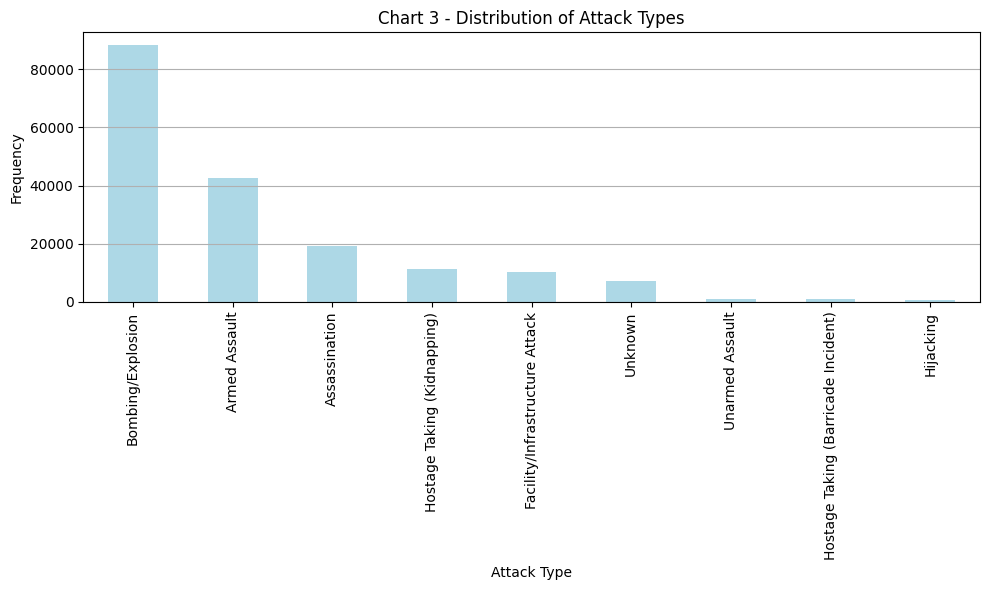

In [24]:
attack_type_counts = df['attacktype1_txt'].value_counts()
plt.figure(figsize=(10, 6))
attack_type_counts.plot(kind='bar', color='lightblue')
plt.title('Chart 3 - Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

* **Why a bar chart?** -
A bar chart is the natural choice for comparing frequencies across discrete, unordered categories. Each bar encodes a single attack type, and its height directly represents occurrence count — enabling immediate rank comparison across all methods without ambiguity. The categorical nature of attack types makes continuous chart forms such as line charts unsuitable.
* **Distribution of attack types(Attack types stratify naturally into three frequency tiers:)**
* Dominant (Bombing / Explosion) -
Overwhelmingly the most prevalent method — accounting for nearly half of all recorded incidents. The preferred tool due to its scalability, anonymity, and mass-casualty potential.
* High frequency (Armed Assault) -
A clear second — substantially less common than bombings but far ahead of other methods. Indicates a strong preference for direct, confrontational violence.
* Moderate (Assassination & Kidnapping) -
The next tier reflects a strategic dimension — targeted elimination and hostage-taking for leverage, ransom, or political coercion.
* Notable (Facility / Infrastructure attack) -
A meaningful share of incidents target physical infrastructure — signalling intent to disrupt essential services, economies, or state symbols.
* Rare (Unarmed assault, barricade incidents & hijacking) - The least common methods — reflecting either high operational complexity (hijacking), limited lethality incentive (unarmed assault), or tactical specificity (barricade incidents) that constrains their adoption by most groups.




**Business Impact**
* **Positive impact (Strategic value of knowing the attack method landscape)** -


1.   Targeted security investment - The clear dominance of bombings and armed assaults enables security agencies and corporations to concentrate resources on detection, hardening, and rapid-response protocols for these specific methods — improving ROI on security spend.
2.   Security technology R&D - Frequency data creates a prioritised product roadmap for security firms — driving investment in explosive detection systems, perimeter barriers, and assault prevention tools where market demand is highest.
1.   Infrastructure resilience planning - The notable prevalence of facility attacks gives critical infrastructure operators — energy, transport, communications — a clear mandate to design targeted resilience frameworks and reduce operational downtime risk.
2.   Emergency preparedness - Knowing the predominant attack types allows healthcare providers and emergency services to pre-configure trauma response capacity and casualty management protocols for the most likely scenarios.

* **Negative growth (Economic consequences of high-prevalence destructive methods)**


1. Physical & economic damage - Bombings and armed assaults cause direct destruction of property, infrastructure, and productive assets — generating reconstruction costs, asset write-offs, and GDP contraction in affected areas.
2.   Human capital loss - High-casualty attack types deplete skilled labour, suppress consumer confidence, and impose lasting healthcare burdens — compounding economic damage well beyond the immediate incident.
1.   Business & commerce disruption - Repeated attacks force temporary or permanent business closures, interrupt supply chains, and create an atmosphere of chronic instability that actively deters commerce, tourism, and new market entry.
2.  Misallocated capital - Mandatory security spending diverts funds from productive investment — R&D, capacity expansion, workforce development — indirectly constraining long-term growth potential for both businesses and governments.




**Chart 4: Bar chart showing top 10 countries with most attacks**

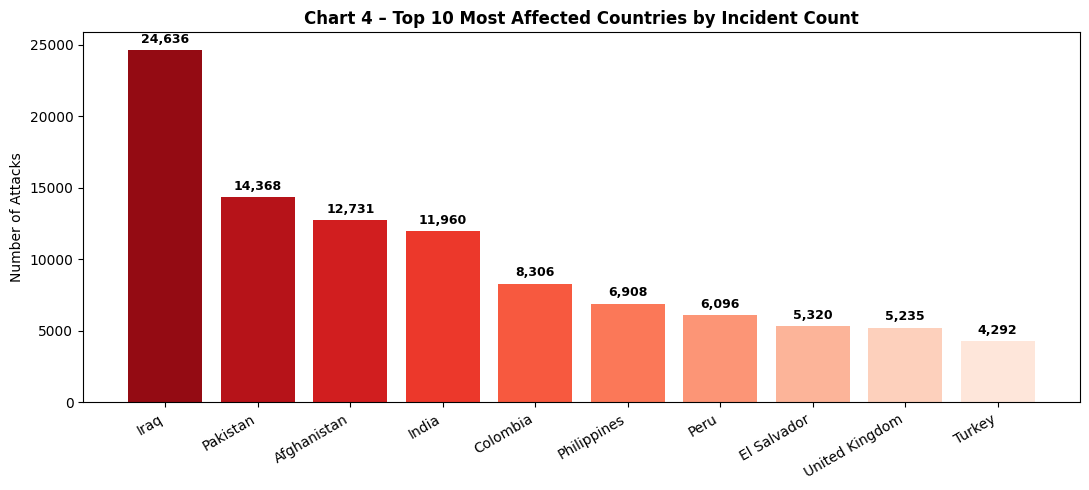

In [25]:
top_countries = df['country_txt'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
palette = sns.color_palette("Reds_r", 10)

bars = ax.bar(top_countries.index, top_countries.values, color=palette)
ax.bar_label(bars, labels=[f"{v:,}" for v in top_countries.values],
             padding=3, fontsize=9, fontweight='bold')

ax.set_title("Chart 4 – Top 10 Most Affected Countries by Incident Count", fontweight="bold")
ax.set_ylabel("Number of Attacks")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()



* **Why a bar chart?** -
A bar chart ranked in descending order is the most effective format for comparing a single metric — attack frequency — across discrete geographic entities. The sorted arrangement instantly surfaces the most affected nations and makes magnitude differences between countries visually proportionate, enabling rapid identification of global hotspots without requiring the reader to interpret complex encodings.
* **Number of terrorist attacks by country — top 15(Four geographic patterns define the distribution:)**
* Apex concentration (Iraq stands alone at the top) - Iraq records a substantially higher attack count than any other nation in the dataset — reflecting the compounded effect of prolonged state fragility, sectarian conflict, and ISIL's territorial expansion in the 2010s.
* Middle East & South Asia (Regional dominance) - Pakistan, Afghanistan, and India consistently rank among the top positions, confirming that the Middle East and South Asia bear a disproportionate share of the global terrorism burden.
* Latin America (Colombia as an outlier) - Colombia's presence in the top 15 underscores that terrorism is not geographically exclusive to conflict-zone regions — insurgent and narco-terrorism have generated sustained high-frequency activity in South America as well.
* Burden distribution (Disproportionate concentration) - A small cluster of nations at the top of the ranking collectively accounts for a large majority of all recorded incidents globally — a classic heavy-tail distribution that signals deep, structural drivers of terrorism rather than diffuse, opportunistic activity.



**Business Impact**
* **Positive impact (Strategic value of geographic concentration data)** -


1.   Geographic risk prioritisation - Country-level rankings allow corporations, insurers, and governments to tier their risk exposure and concentrate security investment and contingency planning in the highest-impact jurisdictions.
2.   Market entry intelligence - Businesses evaluating expansion into emerging markets can use this data to benchmark country risk, adjust entry strategies, and structure operations with appropriate security infrastructure from the outset.

* **Negative growth (Structural consequences of chronic high-frequency attack nations)**


1. Deterred investment & capital flight - Chronic instability in top-ranked countries drives both foreign and domestic capital away — stifling business development, employment creation, and long-term economic expansion.
2.  Infrastructure damage & reconstruction burden - High attack volumes — dominated by bombings — generate recurring costs for repairing public infrastructure and private assets, diverting government resources from productive investment.
1.   Human capital erosion - Sustained high casualty rates deplete skilled workforces, overwhelm healthcare systems, and trigger mass displacement — compressing economic output and long-term development potential.
2.  Trade, tourism & social fragmentation - Persistent insecurity disrupts trade corridors, eliminates tourism revenue, and drives refugee crises — imposing spillover economic burdens on neighbouring countries and undermining regional stability.




**Chart 5: Pie chart showing target types**

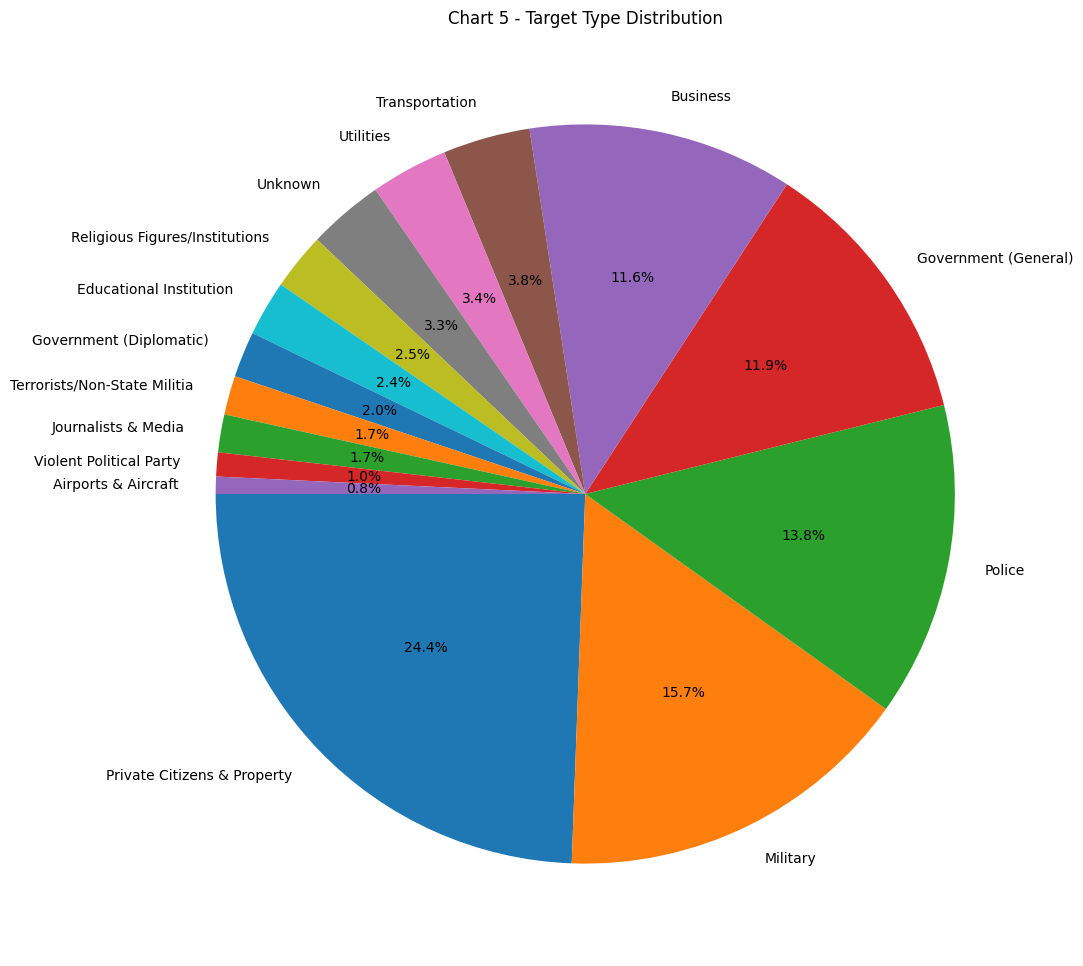

In [26]:
target_types = df['targtype1_txt'].value_counts().head(15)
plt.figure(figsize=(20,12))
plt.pie(target_types.values, labels=target_types.index, autopct='%1.1f%%', startangle=180)
plt.title('Chart 5 - Target Type Distribution')
plt.show()


* **Why a pie chart?** -
A pie chart is appropriate here because the objective is to illustrate proportional composition — how the total volume of attacks is distributed across mutually exclusive target categories. Each sector's arc directly encodes its share of the whole, making it straightforward to identify dominant targets and assess the relative weight of each category within the overall attack landscape.
* **Distribution of target types in terrorist attacks(Target types stratify into three clear frequency tiers:)**
* Primary target (Private citizens & property) - The single largest target category — reflecting a deliberate strategy to maximise civilian fear, casualties, and psychological impact on the general population.
* High frequency (Military, police & government) - State security apparatus and governance structures are the next most targeted — indicating direct ideological confrontation with state authority and attempts to erode institutional legitimacy.
* Significant (Business sector) - Commercial targets are frequently attacked to disrupt economic activity, deter investment, and undermine public confidence in the stability of markets.
* Notable (Transport, utilities & infrastructure) - Attacks on critical services aim to generate cascading disruption — affecting entire economies and populations far beyond the point of attack.
* Moderate (Education & religious institutions) - Targeting these sectors signals an intent to fracture social cohesion, suppress ideology, or intimidate specific community and faith groups.
* Least frequent (Diplomatic, NGOs & non-state actors) - The least targeted categories — though their lower frequency does not diminish the strategic significance of attacks when they do occur



**Business Impact**
* **Positive impact (Value of target-type intelligence for stakeholders)** -


1.   Prioritised security investment - Knowing which sectors are most frequently targeted enables businesses and governments to concentrate protective measures where risk is highest — improving security ROI and reducing exposure for commercial centres, public spaces, and government facilities
2.   Refined insurance risk modelling - Insurers can design more precise, sector-specific terrorism policies by aligning premium structures with empirical target frequency data — offering businesses clearer financial risk transfer mechanisms.
1.   Security product innovation - Target distribution data creates a prioritised development roadmap for security technology firms — directing R&D toward surveillance, infrastructure hardening, and personnel protection for the most vulnerable categories.
2.   Policy & advocacy alignment - Sector-specific targeting patterns inform public policy and business advocacy efforts, enabling more targeted legislative and regulatory frameworks to protect the most at-risk entities.



* **Negative growth (Economic consequences of the target landscape)**


1. Direct asset & revenue losses - Attacks on private citizens, property, and businesses destroy physical assets, reduce consumer activity, and interrupt operations — translating directly into profit erosion, job losses, and GDP contraction.
2.  Investor confidence erosion - Frequent targeting of economic and civilian sectors signals systemic instability, deterring foreign direct investment and capital deployment — compounding long-term growth constraints.
1.   Critical service disruption - Attacks on transportation, utilities, and government infrastructure produce cascading failures across dependent sectors — amplifying economic damage well beyond the immediate point of impact.
2.  Social & human capital costs - Civilian-focused attacks generate casualties, mass displacement, and chronic fear — depleting workforce capacity, suppressing consumer confidence, and imposing long-term public health and productivity burdens.



**Chart 6: Pie chart showing weapon distribution**

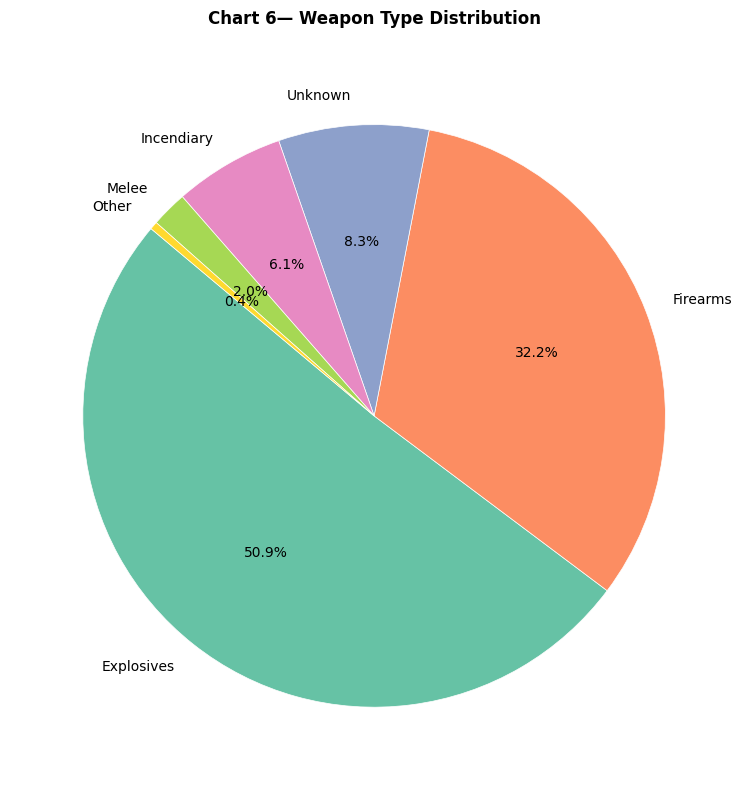

In [27]:
weapon_counts = df['weaptype1_txt'].value_counts()
# Group low-frequency categories into 'Other'
top_weapons = weapon_counts.head(5)
other_count = weapon_counts.iloc[5:].sum()
top_weapons['Other'] = other_count

fig, ax = plt.subplots(figsize=(8, 8))
wedge_props = {'edgecolor': 'white', 'linewidth': 0.5}
ax.pie(top_weapons.values, labels=top_weapons.index, autopct='%1.1f%%',
       startangle=140, wedgeprops=wedge_props,
       colors=sns.color_palette("Set2", len(top_weapons)))
ax.set_title(f"Chart 6— Weapon Type Distribution",
             fontweight="bold", pad=20)
plt.tight_layout()
plt.show()



* **Why a pie chart?** -
A pie chart is well-suited here because the primary objective is to convey proportional share — how the total arsenal of terrorist weaponry is divided across distinct categories. The sector sizes directly encode each weapon type's contribution to the whole, making it immediately apparent which methods dominate and how the remaining share is distributed across minor categories.
* **Weapon type distribution(The distribution is heavily concentrated at the top, with two weapon types accounting for over 83% of all incidents:)**
* Dominant — 50.9% (Explosives) -
The single most prevalent weapon — used in over half of all recorded attacks. Their scalability, range, and capacity for mass casualties make them the weapon of choice across virtually all terrorist typologies.
* High frequency — 32.2% (Firearms) - The second dominant category — widely accessible and operationally flexible, firearms are the primary tool for armed assaults, targeted killings, and direct engagements with security forces.
* Notable — 8.3% (Unknown) - A non-trivial share where weapon type could not be determined — reflecting data gaps in incident reporting, particularly for older records or incidents in remote areas.
* Moderate — 6.1% (Incendiary) - Fire-based weapons represent a meaningful minority — favoured for their ability to cause destruction and psychological impact with relatively simple execution.
* Rare — 2.0% (Melee) -
Low-frequency but non-negligible — typically associated with opportunistic or low-resource attacks where access to conventional weapons is constrained.
* Minimal — 0.4% (Other) - A residual category covering unconventional or unclassified methods — statistically negligible but worth monitoring for emerging threat vectors.



**Business Impact**
* **Positive impact (Strategic value of weapon type intelligence)** -


1.   Counter-IED & detection investment - With explosives accounting for over half of all attacks, security agencies and private operators have a clear mandate to prioritise explosive detection technologies, blast-resistant infrastructure, and counter-IED training programmes — maximising protective impact per security dollar spent.
2.   Firearms control & access policy - The 32.2% share of firearm-based attacks provides evidence-based support for arms control policy, border security investment, and stricter enforcement of weapons trafficking regulations — directly reducing operational capacity of armed groups.
1.   Security product R&D prioritisation - The concentration of risk in two weapon categories creates a clear product roadmap for defence and security technology firms — directing innovation toward blast mitigation, ballistic protection, and perimeter security systems with the broadest commercial application.
2.   Emergency response calibration - Healthcare providers and emergency services can pre-configure trauma response capacity — stockpiling blast injury treatment supplies and training personnel in firearm wound management — aligned with the actual distribution of likely incident types.


* **Negative growth (Economic consequences of explosive and firearm-dominated terrorism)**


1. Mass destruction & reconstruction costs - Explosives cause indiscriminate physical damage to infrastructure, commercial assets, and public property — generating substantial reconstruction expenditure and prolonged economic disruption well beyond the immediate incident.
2.  High casualty rates & human capital loss - Both explosives and firearms are high-lethality weapons — driving the bulk of fatalities and injuries in the dataset. This depletes skilled workforces, strains healthcare systems, and suppresses long-term productivity.
1.   Chronic insecurity & investment deterrence - The widespread availability of these weapon types signals a persistently accessible threat environment — deterring foreign investment, constraining tourism, and suppressing economic activity in affected regions.
2.  Escalating security expenditure - The dual dominance of explosives and firearms forces businesses and governments into continuous, costly security upgrades — diverting capital from productive investment and compressing margins across affected sectors.


**Chart 7: Scatter + Regression Line showing Killed vs Wounded**

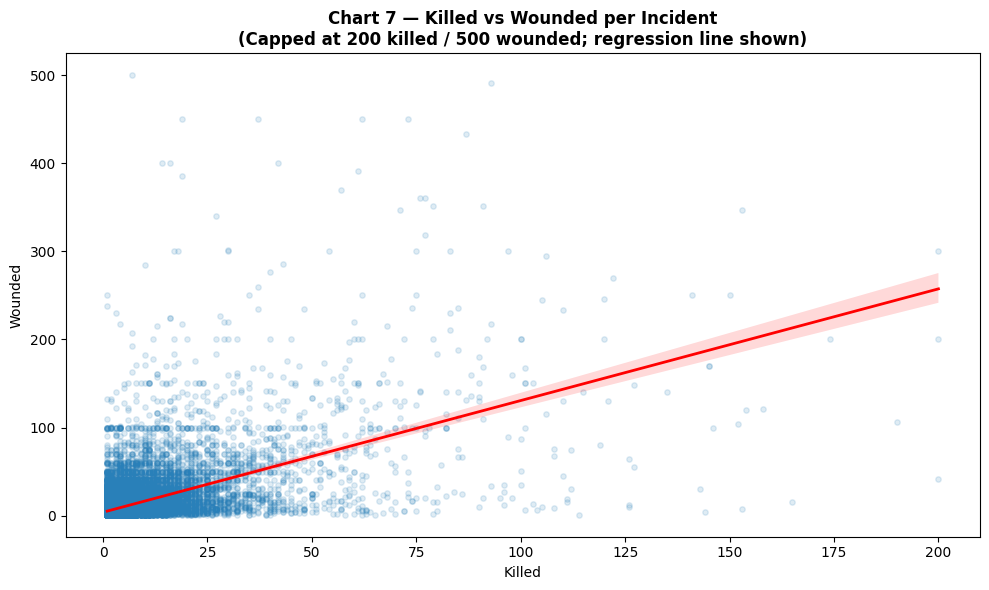

In [28]:
scatter_df = df[(df['nkill'] > 0) & (df['nwound'] > 0) &
                (df['nkill'] <= 200) & (df['nwound'] <= 500)]

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=scatter_df, x='nkill', y='nwound',
            scatter_kws={'alpha': 0.15, 's': 15, 'color': '#2980b9'},
            line_kws={'color': 'red', 'linewidth': 2}, ax=ax)
ax.set_title(f"Chart 7 — Killed vs Wounded per Incident\n"
             f"(Capped at 200 killed / 500 wounded; regression line shown)",
             fontweight="bold")
ax.set_xlabel("Killed")
ax.set_ylabel("Wounded")
plt.tight_layout()
plt.show()

* **Why a scatter plot with regression line?** -
A scatter plot is the most appropriate chart for examining the relationship between two continuous variables — fatalities and injuries per incident. Each data point represents a single attack, allowing the distribution, density, and outliers of the killed-wounded relationship to be observed simultaneously. The overlaid regression line quantifies the directional trend across the dataset, while the shaded confidence band communicates the statistical reliability of that estimate — a level of analytical rigour not achievable with categorical chart types. Capping at 200 killed / 500 wounded preserves visual clarity without discarding the structural patterns in the bulk of the data.
* **Killed vs Wounded per Incident(Five key patterns emerge from the scatter plot:)**
* Dominant — 50.9% (Explosives) -
The single most prevalent weapon — used in over half of all recorded attacks. Their scalability, range, and capacity for mass casualties make them the weapon of choice across virtually all terrorist typologies.
* High frequency — 32.2% (Firearms) - The second dominant category — widely accessible and operationally flexible, firearms are the primary tool for armed assaults, targeted killings, and direct engagements with security forces.
* Notable — 8.3% (Unknown) - A non-trivial share where weapon type could not be determined — reflecting data gaps in incident reporting, particularly for older records or incidents in remote areas.
* Moderate — 6.1% (Incendiary) - Fire-based weapons represent a meaningful minority — favoured for their ability to cause destruction and psychological impact with relatively simple execution.
* Rare — 2.0% (Melee) -
Low-frequency but non-negligible — typically associated with opportunistic or low-resource attacks where access to conventional weapons is constrained.
* Minimal — 0.4% (Other) - A residual category covering unconventional or unclassified methods — statistically negligible but worth monitoring for emerging threat vectors.



**Business Impact**
* **Positive impact (Analytical value of the casualty relationship)** -


1.   Casualty forecasting & preparedness - The positive correlation enables healthcare systems and emergency responders to use fatality estimates as a proxy for expected injury volume — improving pre-deployment of medical resources, triage capacity, and trauma care logistics before full incident data is available.
2.   Insurance severity modelling - The kill-wound relationship provides actuaries with a quantitative basis for modelling total casualty exposure per incident — supporting more accurate pricing of terrorism life, health, and liability insurance products.
1.   Security infrastructure design - The outlier pattern — high wounded at low killed — identifies blast-type incidents in dense environments as disproportionately injurious. This directs investment toward blast mitigation, crowd-space hardening, and rapid evacuation infrastructure where injury reduction potential is highest.
2.   Humanitarian resource allocation - Understanding that most incidents are low-casualty but a small number generate extreme totals allows NGOs to maintain scalable response frameworks — calibrated to the typical case but capable of rapid surge for mass-casualty events.

* **Negative growth (Economic and human consequences of the casualty relationship)**


1. Compounded healthcare burden - The positive kill-wound correlation means high-fatality attacks simultaneously generate large numbers of injured survivors — placing acute and sustained pressure on healthcare infrastructure, public health budgets, and long-term rehabilitation systems.
2.  Amplified human capital loss - Mass-casualty events deplete both the deceased and the wounded from the productive workforce — the injured often face prolonged recovery, disability, or psychological trauma that reduces long-term economic output well beyond immediate mortality figures.
1.  Disproportionate impact of outlier events - The extreme outlier incidents — where hundreds are wounded — cause sudden, severe disruptions to local economies, supply chains, and public confidence that can persist for months or years after the attack itself.
2.  Rising insurance & liability costs - The wide variance in casualty outcomes — even for similar fatality counts — makes risk exposure difficult to bound, driving up insurance premiums and increasing contingent liability provisions for businesses operating in high-risk environments.


**Chart 8: Trend of Terrorist Attacks Over Time**

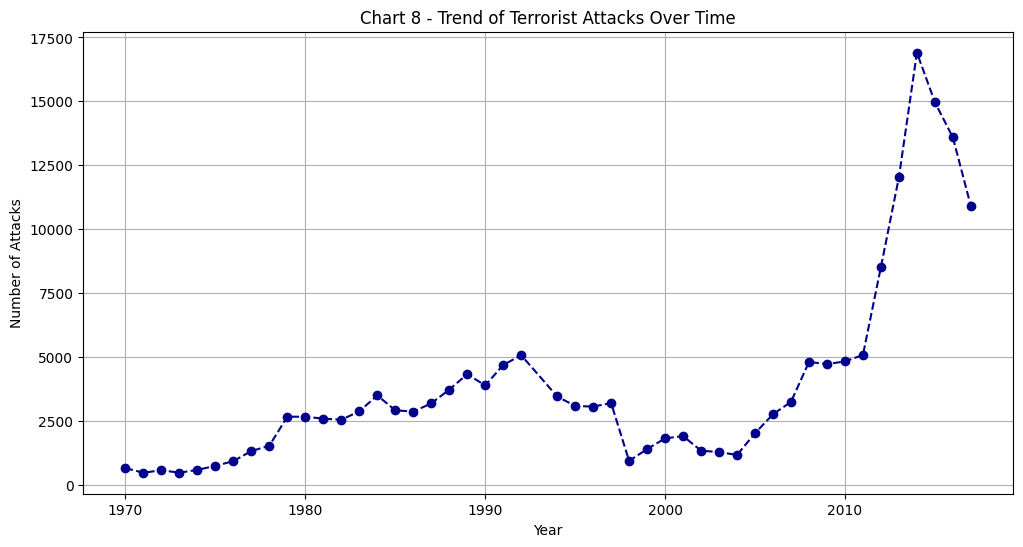

In [29]:
plt.figure(figsize=(12, 6))
attacks_over_time = df['year'].value_counts().sort_index()
plt.plot(attacks_over_time.index, attacks_over_time.values, marker='o',color='darkblue', linestyle='--')
plt.title('Chart 8 - Trend of Terrorist Attacks Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(True)
plt.show()



* **Why a dashed line chart with markers?** -
A dashed line chart with individual data point markers is ideally suited for tracking a single continuous metric — annual attack count — over a 47-year time horizon. The dashed line preserves temporal continuity and directional momentum, while the discrete markers anchor each year's exact value, making it straightforward to identify specific inflection points and year-on-year jumps. This combination is more precise than a smooth area chart for datasets where abrupt single-year transitions — such as the dramatic 2011–2014 surge — are analytically significant.
* **Trend of terrorist attacks over time (1970–2017)(Six distinct phases are visible across the chart:)**

* 1970 – late 1970s (~600 → ~2,700) - A steady early-period rise from a minimal baseline, accelerating sharply toward 1980 as geopolitical tensions and insurgencies intensified globally.

* 1980 – early 1990s (~2,500 – ~5,100) - Sustained elevated activity with a pronounced peak around 1992 — driven by Cold War proxy conflicts, Middle Eastern instability, and Latin American insurgencies.

* Mid-1990s – early 2000s (~1,000 – ~3,200) - A marked trough bottoming near 1998 — the lowest sustained period in the dataset — as several regional conflicts de-escalated and international counter-terrorism frameworks matured.

* 2004 – 2011 (~1,200 → ~5,000) - A decisive and accelerating uptrend — marking the onset of a structurally new era of global terrorism driven by ideologically motivated non-state actors in the Middle East and South Asia.

* 2011 – 2014 — Peak (~5,000 → 16,903) - An unprecedented near-vertical surge — the steepest single multi-year escalation in the dataset — driven by ISIL's rapid territorial expansion and simultaneous conflict escalation across Iraq, Syria, Afghanistan, and Nigeria.

* 2015 – 2017 (15,000 → ~11,000) - A declining trajectory from peak — yet volumes at ~11,000 in 2017 remain more than double any pre-2012 level, confirming a permanently elevated global threat baseline rather than a cyclical correction.


**Business Impact**
* **Positive impact (Strategic value of precise year-level trend data)** -


1.   Inflection-point risk intelligence - The discrete markers allow analysts to pinpoint exact years of escalation onset — enabling governments and corporations to backtest which early signals preceded major surges and incorporate those leading indicators into forward-looking risk models.
2.  Security budget cycle planning - Clear multi-year trend phases provide a structured basis for aligning security spending cycles with threat trajectories — scaling up investment ahead of rising periods and rebalancing allocations during troughs without abandoning readiness.
1.   Policy & counter-terrorism framework design - The identifiable trough of the late 1990s — and the conditions that produced it — offers a policy benchmark for designing effective de-escalation frameworks, international cooperation agreements, and conflict resolution mechanisms.
2.   Investor & market stability signalling - Post-2014 declining markers, even at elevated levels, provide a signal that peak intensity may have passed — enabling cautious re-engagement with previously restricted markets and revision of the most conservative risk discount assumptions.

* **Negative growth (Economic consequences of the post-2011 escalation phase)**


1. Structural investment paralysis - The near-vertical 2011–2014 surge created an environment of acute unpredictability — freezing long-horizon capital deployment decisions in affected regions and driving capital into safer markets, compounding existing economic fragility.
2.  Persistently elevated operational costs - The post-2014 decline to ~11,000 attacks annually — still more than double pre-2012 levels — means businesses cannot revert to pre-surge security cost structures, locking in higher baseline expenditure on security, insurance, and compliance indefinitely.
1.  Supply chain & trade disruption - The sustained high-volume phase from 2012 onwards coincides with significant disruption to key trade corridors in the Middle East and South Asia — driving up logistics costs, increasing transit times, and reducing supply chain reliability for globally integrated industries.
2.  Deterred FDI & tourism recovery - Even as attack counts begin declining post-2014, the perception of instability formed during the peak years persists — delaying investor re-entry and tourism recovery well beyond the point at which objective risk levels have begun to recede.

**Chart 9: Fatality Distribution by Region**

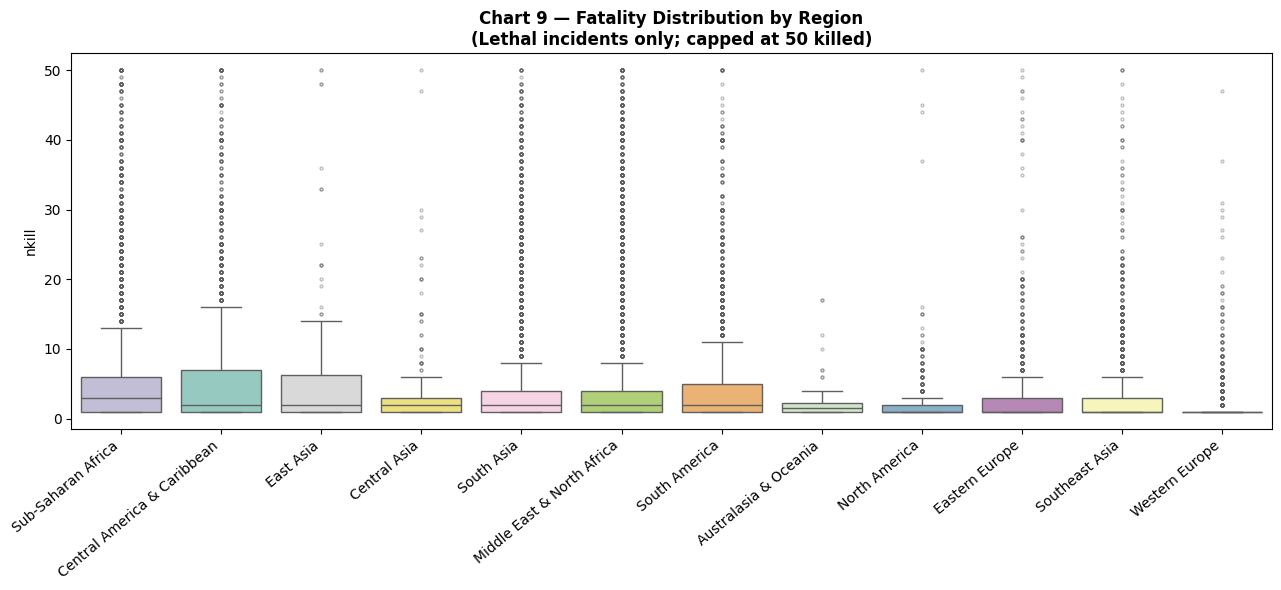

In [30]:
plot_df = df[(df['nkill'] > 0) & (df['nkill'] <= 50)].copy()
region_order = (plot_df.groupby('region_txt')['nkill']
                .median()
                .sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=plot_df, x='region_txt', y='nkill',
            order=region_order, hue='region_txt', legend=False,
            palette="Set3", ax=ax,
            flierprops=dict(marker='o', markersize=2, alpha=0.4))
ax.set_title("Chart 9 — Fatality Distribution by Region\n"
             "(Lethal incidents only; capped at 50 killed)",
             fontweight="bold")
ax.set_xlabel("")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()


* **Why a box plot?** -
A box plot is the most informative format for comparing statistical distributions — median, interquartile range, spread, and outliers — across multiple categories simultaneously. For regional fatality data, this reveals not just which regions record the most deaths per incident but how consistently lethal attacks are, which a simple bar chart would obscure entirely. Capping at 50 killed preserves visual clarity while keeping the IQR boxes legible.
* **Fatality distribution by region (lethal incidents only)**
* Highest median lethality (Central America & Caribbean / Sub-Saharan Africa) - These regions show the highest median kill counts per incident with wide IQR boxes — indicating that when attacks occur, they tend to be consistently more lethal than in other regions.
* Wide spread(East Asia) - A notably broad IQR and long whiskers suggest high variability in attack lethality — some incidents are low-casualty while others are extreme, making risk prediction harder.
* Dense outlier clusters (Sub-Saharan Africa & South Asia) - Both regions exhibit dense clouds of outlier dots extending to 50, indicating recurring high-fatality incidents well above the typical range — consistent with mass-casualty bombings and armed assaults.
* Lowest median lethality (Australasia, North America & Western Europe) - Compact boxes near zero with short whiskers reflect that most incidents in these regions are low-casualty — though outliers confirm that mass-casualty events, while rare, do occur.



**Business Impact**
* **Positive impact (Risk-differentiated regional security planning)** -


1.   Targeted resource deployment - High-median regions like Sub-Saharan Africa and Central America signal where incident-level lethality is structurally elevated — enabling security planners to prioritise protective resources where each attack carries the greatest expected human cost.
2.   Insurance severity calibration - The IQR spread per region allows actuaries to set region-specific severity bands for terrorism policies — moving beyond frequency-only models to incorporate realistic per-incident death toll distributions.

* **Negative growth (Consequences of regionally concentrated high-lethality attacks)**


1. Chronic human capital depletion - Regions with consistently high per-incident fatalities face ongoing workforce erosion — compounding the economic damage of attack frequency with disproportionate loss of life per event.
2.  Suppressed investment in high-IQR regions - Wide fatality spread signals unpredictable severity, which is more destabilising for investors than consistently low lethality — amplifying capital deterrence in already fragile economies.

**Chart 10: Attack Type Vs Target Type**

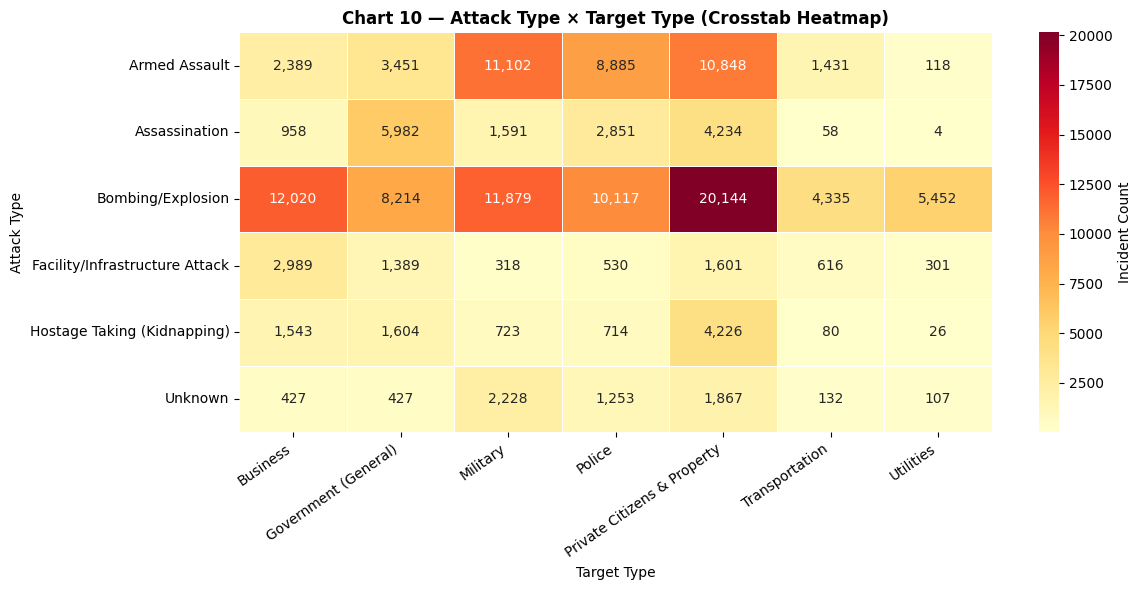

In [31]:
top_atk = df['attacktype1_txt'].value_counts().head(6).index
top_tgt = df['targtype1_txt'].value_counts().head(7).index

filtered = df[df['attacktype1_txt'].isin(top_atk) & df['targtype1_txt'].isin(top_tgt)]
cross = pd.crosstab(filtered['attacktype1_txt'], filtered['targtype1_txt'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(cross, annot=True, fmt=',', cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Incident Count'})
ax.set_title("Chart 10 — Attack Type × Target Type (Crosstab Heatmap)",
             fontweight="bold")
ax.set_xlabel("Target Type")
ax.set_ylabel("Attack Type")
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


* **Why a heatmap?** -
A crosstab heatmap is the ideal format for revealing the interaction between two categorical variables across a matrix of combinations. Colour intensity encodes incident count at each attack-target intersection — allowing the reader to identify dominant pairings, sparse combinations, and strategic patterns at a glance across 42 cells simultaneously, something no bar or line chart could achieve efficiently.
* **Attack type × target type interaction**
* Dominant cell (Bombing → Private Citizens & Property) - The darkest cell in the matrix — bombings targeting civilians represent the single most frequent attack-target combination, reflecting a deliberate strategy to maximise fear and mass casualties.
* Second highest (Bombing → Business) - Commercial targets are the second most bombed category — signalling economic disruption as a primary tactical objective alongside civilian harm.
* Armed assault hotspot (Armed Assault → Military) - Direct armed confrontations with military targets are the most frequent non-bombing pairing — reflecting ideological warfare against state security apparatus.
* Sparsest cells (Utilities & Transportation rows) - These target types attract the fewest incidents across all attack methods — yet their strategic disruption potential means even low-frequency attacks in these cells carry disproportionate economic consequences.

**Business Impact**
* **Positive impact (Precision targeting of security investment)** -


1.   Matrix-guided security protocols - The heatmap enables security managers to design protocols proportionate to actual attack-target frequency — concentrating blast mitigation and crowd-protection measures where the bombing-civilian combination dominates.
2.   Critical infrastructure prioritisation - Low cell counts for utilities and transportation can be misleading — their cascading failure potential justifies disproportionate protective investment relative to raw frequency.

* **Negative growth (Economic consequences of dominant attack-target pairings)**


1. Civilian & commercial sector damage - The concentration of bombings on private citizens and businesses simultaneously destroys consumer confidence, physical assets, and commercial activity — producing compounded economic losses far exceeding the physical damage alone.
2.  State security erosion - The high frequency of armed assaults on military and police targets directly degrades institutional capacity — weakening the state security apparatus that underpins the stable environment businesses require to operate.

**Chart 11: Suicide Vs Non-Suicide Lethality**

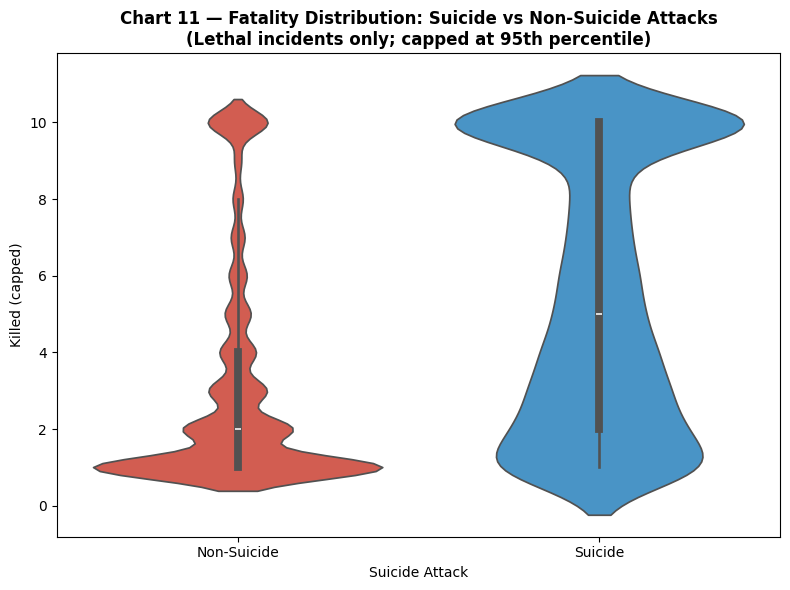

In [32]:
cap = df['nkill'].quantile(0.95)
df['killed_capped'] = df['nkill'].clip(upper=cap)

violin_df = df[df['killed_capped'] > 0].copy()
violin_df['Suicide Attack'] = violin_df['suicide'].map({1: 'Suicide', 0: 'Non-Suicide'})

fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(data=violin_df, x='Suicide Attack', y='killed_capped',
               hue='Suicide Attack', legend=False,
               palette=['#e74c3c', '#3498db'], inner='box', ax=ax)
ax.set_title("Chart 11 — Fatality Distribution: Suicide vs Non-Suicide Attacks\n"
             "(Lethal incidents only; capped at 95th percentile)",
             fontweight="bold")
ax.set_ylabel("Killed (capped)")
plt.tight_layout()
plt.show()


* **Why a violin plot?** -
A violin plot combines the distributional density of a kernel density estimate with the summary statistics of a box plot — making it uniquely suited for comparing the shape of fatality distributions between two groups. Unlike a box plot alone, the width of each violin at any kill count directly encodes probability density, revealing where casualties concentrate and how the two distributions differ in shape, not just central tendency. Capping at the 95th percentile removes extreme outliers that would otherwise compress the main distribution into illegibility.
* **Fatality distribution: suicide vs non-suicide attacks**
* Non-suicide attacks (red) (Concentrated at low lethality) - The red violin is widest near 1–2 killed, tapering sharply upward — confirming that the vast majority of non-suicide attacks produce low fatality counts, with density rapidly declining at higher kill values.

* Suicide attacks (blue) (Broader, higher lethality distribution) - The blue violin is notably wider and more evenly distributed between 2–10 killed, with a higher median (white dot) — confirming that suicide attacks are structurally more lethal per incident than non-suicide attacks.

* Median comparison (Suicide median ~5K vs Non-Suicide ~2K) - The embedded box plot within each violin confirms a materially higher median fatality count for suicide attacks — indicating that the perpetrator's willingness to die correlates directly with greater destructive intent and execution.

* Distribution shape (Suicide attacks show bimodal tendency) - The blue violin's shape suggests two concentration zones — one at low counts and another at 8–10 killed — indicating a subset of suicide attacks specifically designed for mass-casualty outcomes.


**Business Impact**
* **Positive impact (Tactical threat differentiation for preparedness)** -


1.   Differentiated response protocols - The higher and broader lethality profile of suicide attacks justifies dedicated tactical response frameworks — including suicide vest detection, vehicle ramming barriers, and specialised first-responder training distinct from those designed for conventional attacks.
2.   Insurance severity segmentation - The distributional difference between the two attack types enables insurers to create separate risk pools and premium structures for policies covering environments where suicide attacks are prevalent versus those where they are rare.
* **Negative growth (Consequences of suicide attack lethality premium)**


1. Disproportionate mass-casualty risk - The wider, higher-median distribution of suicide attacks means that any increase in their prevalence produces a non-linear escalation in total fatalities — amplifying human capital loss and healthcare burden well beyond proportionate frequency growth.
2.  Heightened public fear & economic paralysis - The unpredictable and indiscriminate nature of suicide attacks in public spaces suppresses consumer movement and commercial activity more severely than equivalent-frequency conventional attacks — disproportionately damaging retail, tourism, and hospitality sectors.


**Chart 12: Yearly Attack Trend**

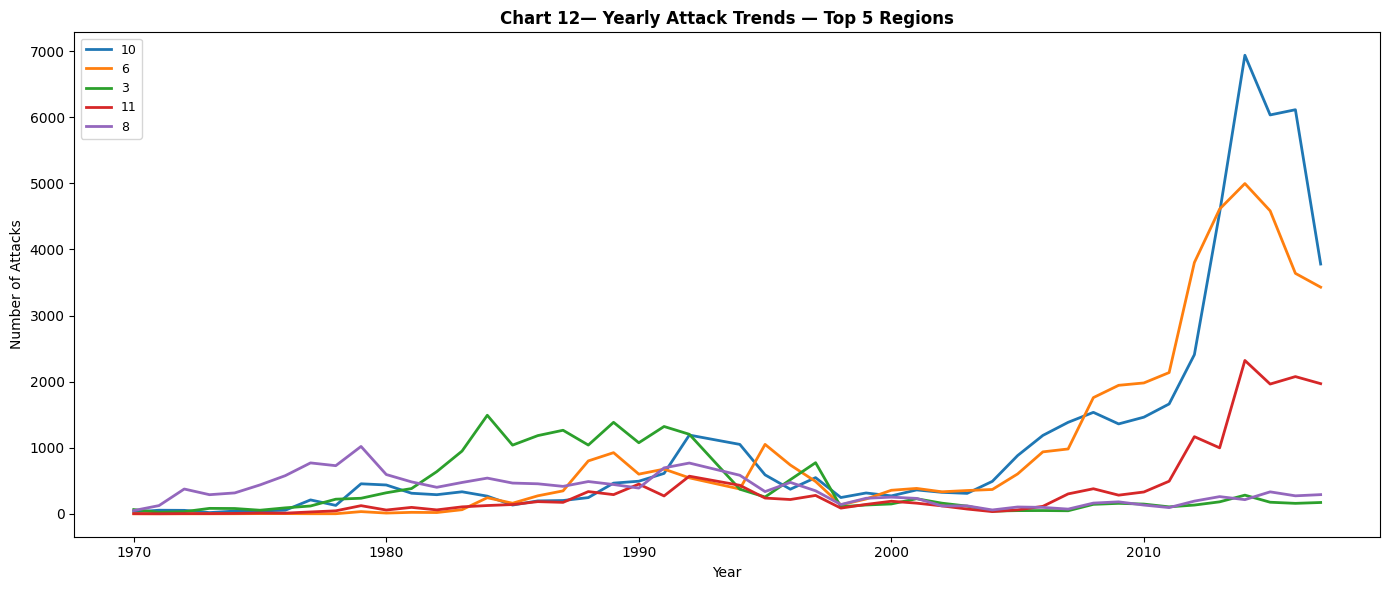

In [33]:
top5_regions = df['region'].value_counts().head(5).index
region_year = (df[df['region'].isin(top5_regions)]
               .groupby(['year', 'region'])
               .size()
               .reset_index(name='count'))

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette("tab10", 5)
for i, region in enumerate(top5_regions):
    data = region_year[region_year['region'] == region]
    ax.plot(data['year'], data['count'], label=region,
            color=palette[i], linewidth=2)

ax.set_title(f"Chart 12— Yearly Attack Trends — Top 5 Regions",
             fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Attacks")
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

* **Why a multi-line chart?** -
A multi-line chart is the most effective format for simultaneously comparing temporal trajectories across multiple series. Each coloured line traces an individual region's annual attack count, allowing the reader to identify diverging trends, regional decoupling, and convergence events across the 47-year period. Unlike a stacked chart, individual lines preserve the true scale of each region's evolution without distortion from cumulative stacking.
* **Yearly attack trends — top 5 regions (1970–2017)**
* Dominant surge (~7,000 at peak Region 10 (Middle East & North Africa) — blue line) - Far outpaces all other regions post-2011, peaking at approximately 7,000 attacks in 2014. Its near-vertical rise from 2011 is the single most defining feature of the chart — reflecting ISIL's territorial expansion across Iraq and Syria.

* Second highest surge (~5,000 at peak Region 6 (South Asia) — orange line) - A sharp escalation from 2011 peaking around 5,000 in 2014, then declining — driven by conflict escalation in Afghanistan and Pakistan concurrent with the global terrorism peak.

* Historical leader (Region 3 (South America) — green line) - Dominant in the 1980s–early 1990s, then declining sharply from the mid-1990s as Colombian and Peruvian insurgencies de-escalated — now among the lowest of the five lines.

* Late escalation (Region 11 (Sub-Saharan Africa) — red line) - Relatively flat until approximately 2010, then rises sharply to ~2,000 — reflecting Boko Haram's rapid escalation in Nigeria and Al-Shabaab activity in East Africa.


**Business Impact**
* **Positive impact (Region-specific strategic planning value)** -


1.   Divergence-based risk reallocation - The visible decoupling of South America's decline from MENA's surge allows businesses and insurers to dynamically reallocate risk provisions — reducing exposure in de-escalating regions while scaling up in newly high-risk ones.
2.   Early warning from trailing regions - Sub-Saharan Africa's late escalation pattern — flat then sudden surge — serves as a template for identifying early signals of emerging regional threats before they reach peak intensity.

* **Negative growth (Economic consequences of regional divergence)**


1. Concentrated economic damage in MENA & South Asia - The simultaneous surge of the two largest lines post-2011 means the world's most commercially vital regions — oil-producing MENA and trade-critical South Asia — experienced peak instability concurrently, amplifying global supply chain and energy market disruption.
2.  Emerging market growth suppression - Sub-Saharan Africa's late escalation coincides with a period of anticipated high growth for African economies — directly suppressing FDI inflows, infrastructure investment, and the economic development gains projected for the region.

**Chart 13: Weapon X Region X Casualties**

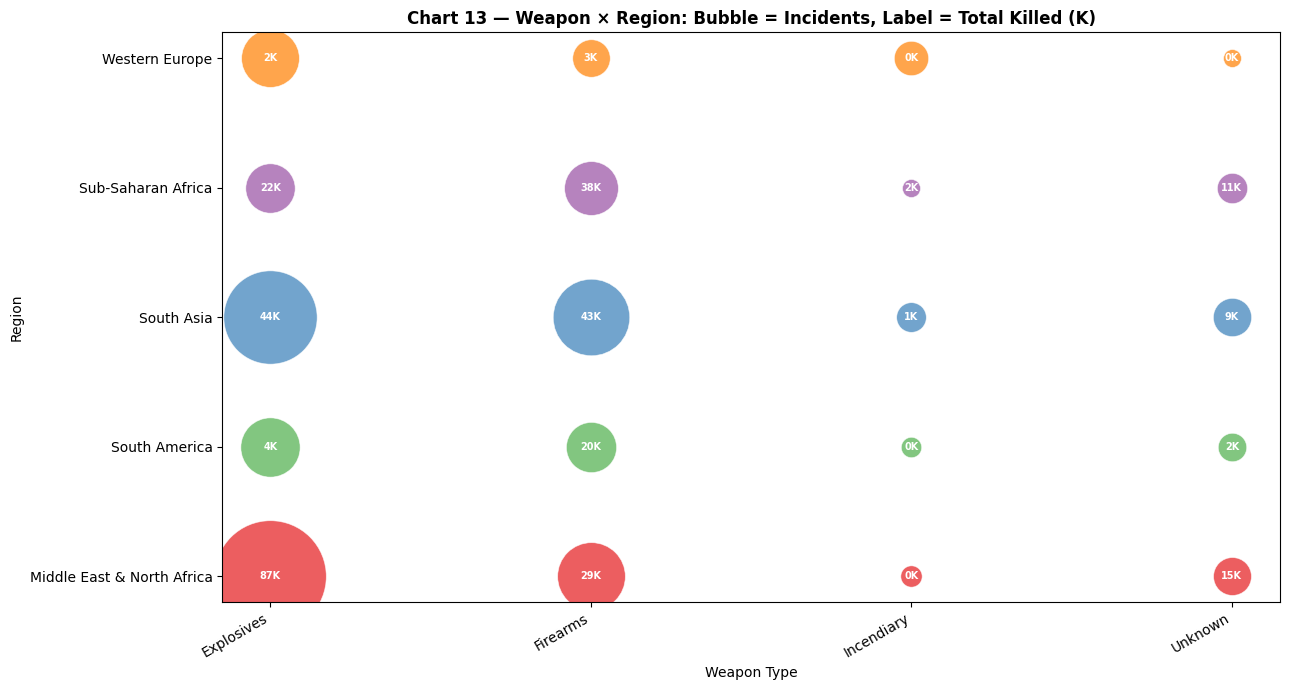

In [34]:
top_weapons_list = df['weaptype1_txt'].value_counts().head(4).index
top_regions_list = df['region_txt'].value_counts().head(5).index

bubble_df = (df[df['weaptype1_txt'].isin(top_weapons_list) &
               df['region_txt'].isin(top_regions_list)]
             .groupby(['region_txt', 'weaptype1_txt'])
             .agg(incidents=('iyear', 'count'), total_kill=('nkill', 'sum'))
             .reset_index())

fig, ax = plt.subplots(figsize=(13, 7))
palette_b = sns.color_palette("Set1", len(top_regions_list))
region_color = {r: palette_b[i] for i, r in enumerate(top_regions_list)}

for _, row in bubble_df.iterrows():
    ax.scatter(row['weaptype1_txt'], row['region_txt'],
               s=row['incidents'] / 5,
               color=region_color[row['region_txt']],
               alpha=0.7, edgecolors='white', linewidths=0.5)
    ax.annotate(f"{int(row['total_kill']/1000)}K",
                (row['weaptype1_txt'], row['region_txt']),
                ha='center', va='center', fontsize=7, fontweight='bold',
                color='white')

ax.set_title("Chart 13 — Weapon × Region: Bubble = Incidents, Label = Total Killed (K)",
             fontweight="bold")
ax.set_xlabel("Weapon Type")
ax.set_ylabel("Region")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

* **Why a bubble chart?** -
A bubble chart encodes three variables simultaneously across a two-dimensional matrix — weapon type (x-axis), region (y-axis), and incident count (bubble size) — with total killed labelled directly on each bubble. This three-variable encoding enables the reader to identify not just which weapon-region combinations are most frequent, but also where high incident counts translate into disproportionately high fatalities and where they do not — a nuance no two-variable chart can capture.
* **Weapon × region: incident volume and total killed**
* Largest bubble (7K killed, MENA — Explosives) - The dominant cell in the entire chart — the Middle East & North Africa with explosives produces both the highest incident volume and the highest total fatalities by a significant margin, underscoring the catastrophic human cost of this specific combination.

* High lethality (44K / 43K killed, South Asia — Explosives & Firearms) - South Asia records near-equal fatality totals from both explosives and firearms — indicating a diverse weapon arsenal rather than reliance on a single method, making threat mitigation more complex.

* High incidents, lower killed ratio (38K killed, Sub-Saharan Africa — Firearms) - A large firearms bubble with substantial kill count — reflecting the prevalence of armed group activity across Central and East Africa where firearms are the primary operational weapon.

* Minimal lethality (Western Europe — all weapons) - Small bubbles and near-zero kill labels across all weapon types confirm that while Western Europe records incidents, their lethality is structurally low relative to other regions — reflecting effective security infrastructure and lower-intensity attack methods.


**Business Impact**
* **Positive impact (Weapon-region intelligence for targeted intervention)** -


1.   Prioritised counter-weapon investment by region - The matrix directly identifies where counter-IED programmes deliver the greatest human-cost reduction (MENA, South Asia) versus where firearms interdiction and arms trafficking controls should be prioritised (Sub-Saharan Africa, South Asia).
2.   Corporate supply chain risk mapping - Businesses with operations across multiple regions can use the bubble chart to identify their highest weapon-exposure intersections and structure security protocols and insurance coverage accordingly.

* **Negative growth (Economic consequences of weapon-region concentration)**


1. MENA explosive dominance (energy market risk) - The 87K killed MENA-explosives cell represents sustained mass destruction in the world's most energy-critical region — directly threatening oil infrastructure, export capacity, and global energy price stability with every major incident.
2.  Dual-weapon complexity in South Asia - The near-equal fatality contribution of both explosives and firearms in South Asia means that neutralising one weapon type provides limited overall risk reduction — requiring more costly, multi-pronged security and policy interventions to meaningfully reduce the human toll.


# Hypothesis Testing
---

### Hypothesis 1 — Mean Lethality: Suicide vs. Non-Suicide Attacks

- **H₀:** The mean number of people killed in suicide attacks equals the mean in non-suicide attacks.
- **H₁:** Suicide attacks have a significantly higher mean number of people killed.

In [35]:
from scipy import stats

suicide_kills    = df_clean[df_clean['suicide'] == 1]['nkill']
nonsuicide_kills = df_clean[df_clean['suicide'] == 0]['nkill']

print(f"Suicide attacks    — Mean Killed : {suicide_kills.mean():.2f}  | n = {len(suicide_kills):,}")
print(f"Non-suicide attacks— Mean Killed : {nonsuicide_kills.mean():.2f}  | n = {len(nonsuicide_kills):,}")

Suicide attacks    — Mean Killed : 10.13  | n = 6,633
Non-suicide attacks— Mean Killed : 1.97  | n = 175,058


In [36]:
# ── Welch's t-test (unequal variance assumed) ───────────────────────────
t_stat, p_value = stats.ttest_ind(suicide_kills, nonsuicide_kills, equal_var=False)

print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.2e}")

alpha = 0.05
if p_value < alpha:
    print(f"\nResult: Reject H₀ (p < {alpha}) → Suicide attacks ARE significantly more lethal.")
else:
    print(f"\nResult: Fail to reject H₀ (p ≥ {alpha})")

T-statistic : 21.4910
P-value     : 4.03e-99

Result: Reject H₀ (p < 0.05) → Suicide attacks ARE significantly more lethal.


**Test Used:** Welch's two-sample t-test (appropriate because sample sizes and variances differ greatly).

**Interpretation:**
- p-value ≪ 0.05 → We **reject H₀**.
- Suicide attacks cause significantly more deaths on average than non-suicide attacks.
- This confirms that suicide-attack tactics are deliberately designed for maximum lethality.

**Business Impact:** Response protocols triggered by confirmed suicide-attack incidents should automatically escalate to mass-casualty level, even before casualty counts are confirmed.

# ML Model Implementation
---

In [37]:
# Taking cleaned copy of the dataset for ml integration
df_ml = df_clean.copy()
df_ml.fillna('Unknown', inplace=True)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_ml.columns:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

In [38]:
# Use sample for faster training
df_ml = df_ml.sample(n=3000, random_state=42)

In [39]:
X = df_ml.drop('attacktype1_txt', axis=1)
y = df_ml['attacktype1_txt']
from sklearn.model_selection import train_test_split

# X = features, y = target (make sure these are already defined)
# Example:
# X = df.drop('target_column', axis=1)
# y = df['target_column']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,   # 20% test data
    random_state=42  # for reproducibility
)

###**1. Logistic Regression**

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_lr = LogisticRegression(max_iter=200, solver='liblinear')

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.745


In [41]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr, zero_division=0))

              precision    recall  f1-score   support

           0       0.56      0.91      0.69       133
           1       0.44      0.19      0.26        64
           2       0.94      0.99      0.97       292
           3       0.57      0.12      0.20        33
           5       0.00      0.00      0.00         1
           6       0.55      0.12      0.20        49
           7       0.00      0.00      0.00         4
           8       0.45      0.62      0.53        24

    accuracy                           0.74       600
   macro avg       0.44      0.37      0.36       600
weighted avg       0.73      0.74      0.70       600



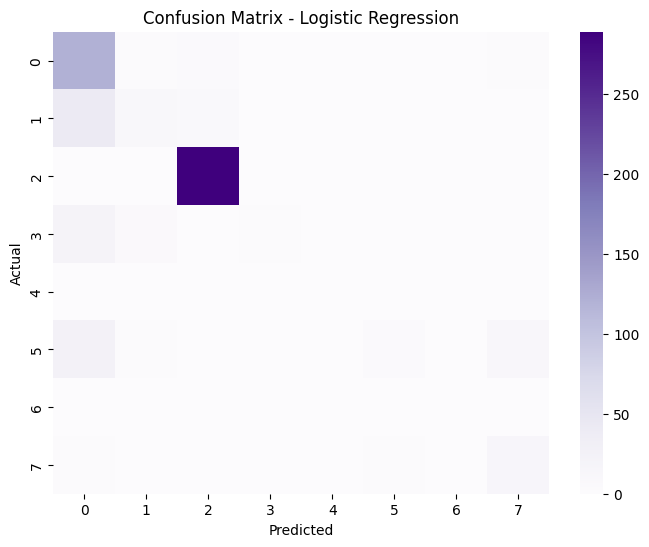

In [42]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8,6))
sns.heatmap(cm_lr, cmap='Purples', cbar=True)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Logistic Regression performs reasonably well for dominant classes such as class 2, but struggles with less frequent classes. This is due to its linear nature, which limits its ability to capture complex relationships in the data.

###**2. Decision Tree**

In [43]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=10, random_state=42)

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7883333333333333


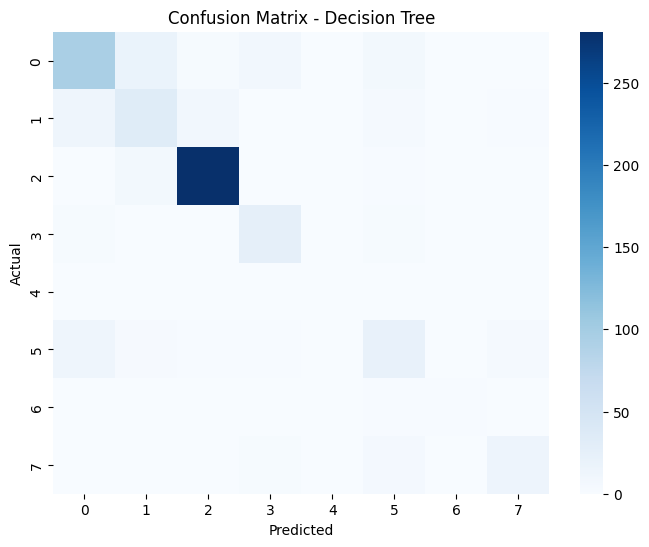

In [44]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8,6))
sns.heatmap(cm_dt, cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree performs better than Logistic Regression by capturing non-linear patterns. It shows improved classification across multiple classes, especially for classes with moderate frequency.

###**3. Naive Bayes**

In [45]:
from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()

model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.5066666666666667


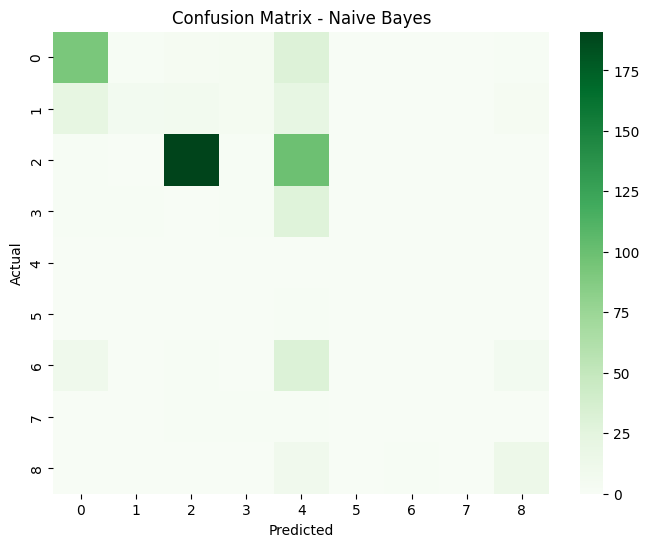

In [46]:
# Confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8,6))
sns.heatmap(cm_nb, cmap='Greens')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Naive Bayes performs well for dominant classes but shows limitations due to its assumption of feature independence, leading to misclassification in overlapping categories.

###**4. K Nearest Neighbours**

In [47]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [48]:
model_knn = KNeighborsClassifier(n_neighbors=5)

model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

from sklearn.metrics import accuracy_score
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.635


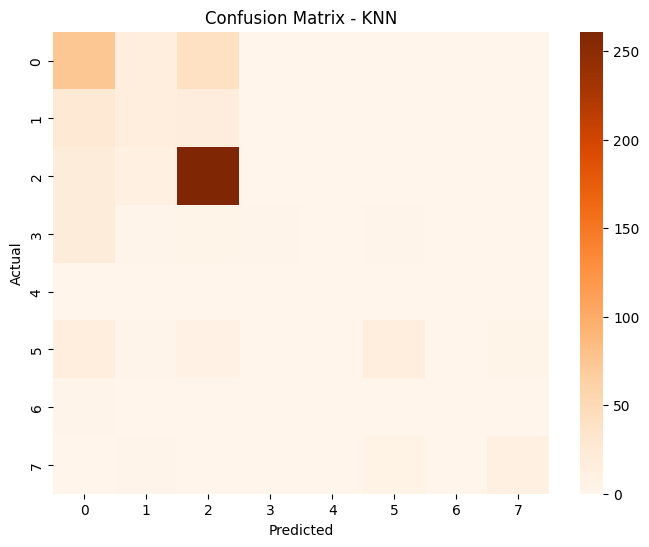

In [49]:
# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8,6))
sns.heatmap(cm_knn, cmap='Oranges')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

KNN performs well due to its distance-based approach, capturing local patterns effectively. It provides strong classification performance, especially for well-separated classes.

###**5. Agglomerative Clustering**

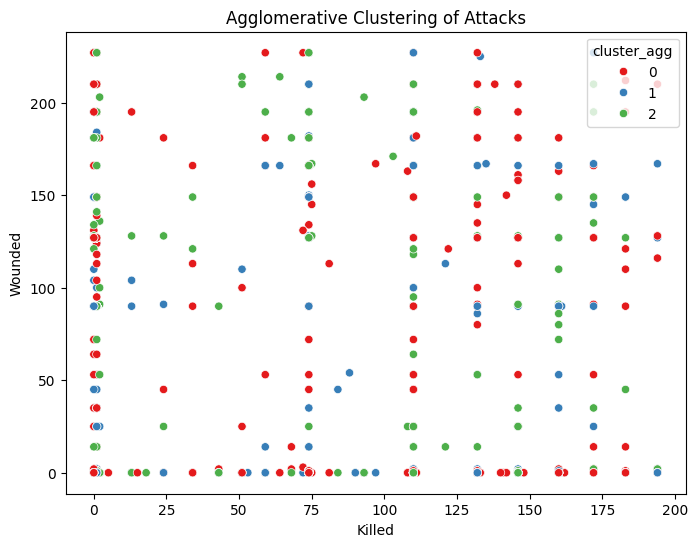

In [50]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=3)

df_ml['cluster_agg'] = agg.fit_predict(X)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df_ml['nkill'],
    y=df_ml['nwound'],
    hue=df_ml['cluster_agg'],
    palette='Set1'
)

plt.title("Agglomerative Clustering of Attacks")
plt.xlabel("Killed")
plt.ylabel("Wounded")
plt.show()

Agglomerative Clustering was used to group similar terrorist incidents based on their features. It forms clusters hierarchically by merging similar data points, helping identify patterns in the data. Since it is an unsupervised method, accuracy and confusion matrix are not applicable.

###**6. Hierarchical clustering**

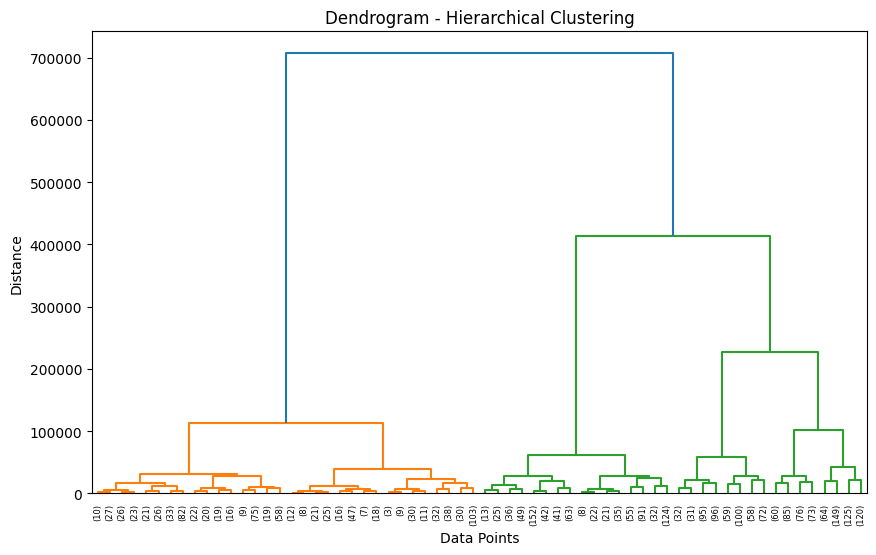

In [51]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Dendrogram - Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

The dendrogram shows how clusters are formed at different distance levels. It helps in deciding the number of clusters by observing where large vertical gaps occur.

###**Accuracy Comparison**

In [52]:
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Naive Bayes:", accuracy_score(y_test, y_pred_nb))
print("KNN:", accuracy_score(y_test, y_pred_knn))

Logistic Regression: 0.745
Decision Tree: 0.7883333333333333
Naive Bayes: 0.5066666666666667
KNN: 0.635


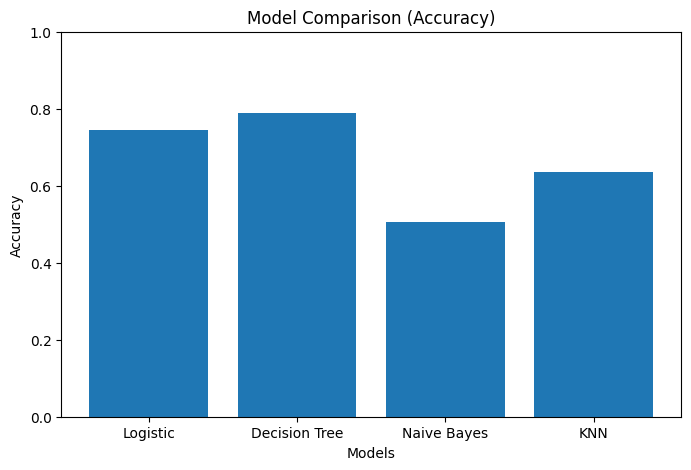

In [53]:
models = ['Logistic', 'Decision Tree', 'Naive Bayes', 'KNN']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_knn)
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Comparison (Accuracy)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

# Conclusion

---

## EDA Conclusions

### Geographic Concentration
Terrorism incidents are highly concentrated in:
- Middle East  
- South Asia  
- Sub-Saharan Africa  

Geopolitical instability and active conflict zones are major driving factors behind this concentration.

---

### Temporal Surge (2011–2017)
A sharp increase in attacks is observed between **2011 and 2017**.  
This period reflects:
- Escalation of global conflicts  
- Rise of organized extremist groups  

---

###  Dominant Attack Method
**Bombings and explosions** are the most common attack methods across regions.  
This indicates a preference for:
- High-impact attacks  
- Easily deployable techniques  

---

### Target Selection
Most frequent targets include:
- Civilians  
- Military personnel  
- Government institutions  

This suggests both:
- **Symbolic targeting** (fear & visibility)  
- **Strategic targeting** (institutional disruption)  

---

### Actor Concentration
A small number of terrorist organizations account for a large proportion of incidents.  
This implies:
- Focused intelligence efforts on key groups can significantly reduce attacks  

---

## ML Conclusions

### Logistic Regression — Stable Baseline
- Provides a reliable starting point  
- Highly interpretable  
- Limited in capturing complex non-linear relationships  

---

###  Decision Tree — Best Performer
- Effectively models non-linear patterns  
- Offers strong interpretability  
- Achieves the best balance between **accuracy and explainability**  

---

### Naive Bayes — Fast but Moderate
- Fast and computationally efficient  
- Moderate performance  
- Assumption of feature independence limits effectiveness on complex datasets  

---

### KNN — Limited by Dimensionality
- Lower performance in high-dimensional data  
- Sensitive to feature scaling  
- Struggles when features are not well separated  

---

### Agglomerative Clustering — Pattern Discovery
- Bottom-up hierarchical clustering approach  
- Identifies natural groupings within the dataset  
- Useful for understanding regional and attack-type similarities  
- Not evaluated using accuracy (unsupervised learning focus)  

---

### Hierarchical Clustering — Multi-Level Insights
- Builds a full **dendrogram** to represent nested cluster relationships  
- Enables analysis at multiple levels of granularity  
- Helps reveal deeper structural patterns across incidents  
- Useful for identifying layered similarities in attack profiles  

---

## Overall Conclusion

The integration of **EDA and Machine Learning** provides both:

- **Descriptive insights** → Understanding patterns and trends  
- **Predictive insights** → Forecasting and classification  

This combined approach supports **data-driven and informed decision-making** in analyzing global terrorism.

---

## Approach Summary

| Approach | Role |
|---------|------|
| **Exploratory Data Analysis** | Uncovers patterns, trends, and distributions |
| **Supervised Machine Learning** | Predicts and classifies outcomes |
| **Unsupervised Machine Learning** | Reveals hidden groupings in data |
| **Combined Insight** | Enables informed counter-terrorism strategies |

---